# Relatório 6: Depth Map — Mapa de Profundidade

---

### **INTEGRANTES**
* Eduarda Alexandre de Salles
* Paloma Santana
* Gustavo Souza

---

### **CRONOGRAMA DO PROJETO**
* **Data de realização dos experimentos:** 13 de julho de 2026 (aula) e sessão complementar de aprofundamento ("aula 2")
* **Data de publicação do relatório:** 20 de julho de 2026

---

### **DISCIPLINA**
ESZA019 – Visão Computacional (2026.2) — UFABC

---

### Declaração de uso de Ferramentas de Inteligência Artificial Generativa (IAG)

Em atendimento à Portaria CNPq nº 2664/2026 (mencionada no roteiro do Laboratório 6), declaramos que a ferramenta de IA generativa **Claude (Anthropic)** foi utilizada neste relatório exclusivamente para:

- **organizar e formatar** o conteúdo já produzido pelo grupo durante as aulas (código, saídas de execução, imagens e vídeos gerados no notebook `Lab6.ipynb` original) na estrutura de seções exigida pelo roteiro (Introdução, Fundamentação Teórica, Procedimentos, Análise, Conclusões, Referências);
- **redigir o texto explicativo e teórico** (introdução, fundamentação teórica, discussões) que acompanha os resultados;
- **elaborar o diagrama de blocos** solicitado no item 2 do roteiro.

Todo o **código-fonte, os experimentos, as capturas de imagem/vídeo e os resultados numéricos** apresentados neste relatório foram integralmente desenvolvidos e executados pelo grupo durante as aulas, nos seus próprios computadores e com sua própria câmera estéreo — nenhum código ou resultado experimental foi gerado pela IA. Os autores permanecem integralmente responsáveis pelo conteúdo final deste relatório, incluindo eventuais imprecisões.

---

# 1. INTRODUÇÃO

Este relatório documenta o experimento de **estimativa de profundidade a partir de um par de câmeras estéreo** (Laboratório 6). O objetivo é, a partir de duas câmeras posicionadas lado a lado (câmera estéreo), medir a distância de objetos reais até a câmera, usando apenas visão computacional — sem sensores de profundidade dedicados (LiDAR, infravermelho, etc.).

O princípio é o mesmo usado pela visão binocular humana: como as duas câmeras enxergam a cena a partir de posições ligeiramente diferentes, um mesmo ponto do mundo aparece deslocado horizontalmente entre a imagem esquerda e a imagem direita — esse deslocamento é chamado de **disparidade**. Quanto mais próximo o objeto está da câmera, maior a disparidade; quanto mais distante, menor a disparidade (e no limite, no infinito, a disparidade tende a zero). Essa relação inversa entre disparidade e distância é o que permite converter um **mapa de disparidade** em um **mapa de profundidade**.

Para que essa relação geométrica seja válida ponto a ponto, as duas imagens precisam antes ser **retificadas**: um processo que alinha as duas câmeras virtualmente de forma que linhas correspondentes do mundo real apareçam exatamente na mesma linha horizontal (mesma coordenada *y*) em ambas as imagens — isso reduz a busca por correspondências de um problema 2D para um problema 1D (apenas ao longo da linha), o que é o que viabiliza os algoritmos de *Block Matching* usados na prática.

O relatório está organizado seguindo as etapas do roteiro: **(i)** calibração estéreo (repetindo e refinando o procedimento da aula anterior de calibração, mas agora para o par de câmeras); **(ii)** cálculo do mapa de disparidade via *Block Matching*, com sintonia dos parâmetros do algoritmo; **(iii)** conversão do mapa de disparidade em mapa de profundidade métrico (centímetros reais); e **(iv)-(vi)** medição prática da distância de objetos usando o sistema calibrado.

# 2. FUNDAMENTAÇÃO TEÓRICA

### 2.1 Geometria epipolar e visão estéreo

Quando duas câmeras observam a mesma cena a partir de posições diferentes, um ponto 3D do mundo $P$ se projeta em pontos diferentes $p_L$ e $p_R$ nas imagens esquerda e direita. A **geometria epipolar** descreve a relação entre essas duas projeções: dado um ponto $p_L$ na imagem esquerda, seu correspondente $p_R$ na imagem direita está restrito a estar sobre uma reta específica — a **linha epipolar** — o que reduz drasticamente o espaço de busca de correspondências entre as duas imagens (de uma busca 2D para uma busca 1D). Quando as duas câmeras são **retificadas** (seus planos de imagem alinhados e coplanares, com eixos ópticos paralelos), as linhas epipolares tornam-se horizontais e coincidentes entre as duas imagens — ou seja, um ponto na linha $y$ da imagem esquerda só pode corresponder a um ponto na **mesma linha $y$** da imagem direita. Essa é a condição que o processo de calibração e retificação estéreo (`cv2.stereoCalibrate` + `cv2.stereoRectify`) busca garantir.

### 2.2 Mapa de disparidade (Block Matching)

Com as imagens retificadas, a **disparidade** $d$ de um ponto é a diferença horizontal (em pixels) entre sua posição na imagem esquerda e na imagem direita: $d = x_L - x_R$. O algoritmo de **Block Matching** (`cv2.StereoBM`, ou sua variante semi-global `cv2.StereoSGBM`) percorre pequenos blocos de pixels da imagem esquerda e busca, ao longo da linha epipolar correspondente na imagem direita, o bloco mais parecido (por correlação/soma de diferenças absolutas), dentro de uma faixa de disparidades possíveis (`numDisparities`). O resultado é o **mapa de disparidade**: uma imagem em que cada pixel contém o valor de disparidade estimado naquele ponto. Diversos parâmetros de sintonia (`blockSize`, `uniquenessRatio`, `speckleWindowSize`, `preFilterCap`, `textureThreshold`, entre outros) controlam o compromisso entre densidade (quantos pixels recebem uma disparidade válida) e robustez a ruído/regiões sem textura.

### 2.3 Do mapa de disparidade ao mapa de profundidade

Pela semelhança de triângulos entre os dois centros ópticos das câmeras e o ponto observado, a profundidade $Z$ (distância do ponto até o plano da câmera) relaciona-se com a disparidade $d$ por:

$$ Z = \frac{f \cdot B}{d} $$

onde $f$ é a distância focal (em pixels, obtida na calibração) e $B$ é a **baseline** — a distância física entre os centros ópticos das duas câmeras (obtida como $|T|$ na calibração estéreo). Como o produto $f \cdot B$ é uma constante do sistema (para uma dada câmera estéreo fixa), essa relação pode ser reescrita como $Z = M/d$, com $M = f \cdot B$ determinado empiricamente. Na prática, efeitos como offsets de calibração e não-linearidades do sensor fazem com que um modelo com um termo de deslocamento adicional, $Z = M/d + C$, ajuste melhor os dados reais — os coeficientes $M$ e $C$ são então obtidos por regressão (mínimos quadrados) a partir de pares (disparidade medida, distância real conhecida).

### 2.4 Diagrama de blocos do experimento

O diagrama abaixo resume o fluxo completo, da construção física da câmera estéreo até a medição de distância de um objeto:

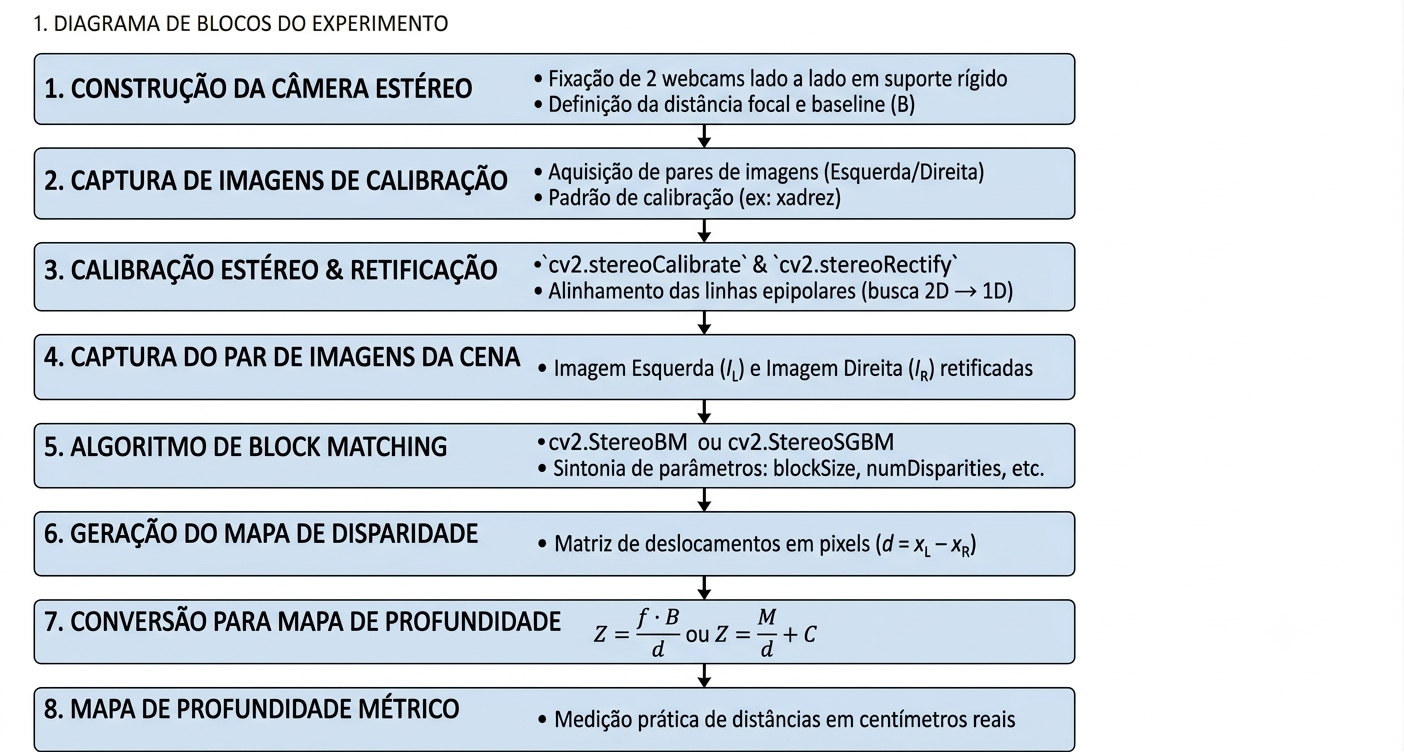

# 3. PROCEDIMENTOS EXPERIMENTAIS

O grupo utilizou a câmera estéreo (duas webcams fixadas lado a lado sobre um suporte rígido) construída na aula anterior. Os experimentos foram realizados em **duas sessões**: uma sessão inicial (arquivos da pasta `lab6/`, script-base fornecido pelo professor) e uma sessão de aprofundamento, "aula 2" (pasta `lab6aula2/`), na qual o grupo refinou a calibração, implementou uma interface de sintonia mais completa para o *Block Matching* e um ajuste por mínimos quadrados para o mapa de profundidade. Por transparência, os resultados de **ambas as sessões são apresentados**, pois cada uma gerou uma calibração numericamente distinta da câmera estéreo montada pelo grupo.

Todo o código abaixo é o código **efetivamente executado pelo grupo em aula** (arquivo `Lab6.ipynb`), incluindo as saídas (números, imagens, logs) obtidas na própria máquina do grupo, com sua câmera estéreo física conectada. Como esses scripts dependem de hardware (duas webcams) e de janelas interativas do OpenCV (`cv2.imshow`, *trackbars*) que não existem neste ambiente de formatação do relatório, o código **não foi reexecutado aqui** — apenas reorganizado, com as saídas originais preservadas exatamente como produzidas em aula.

## 3.0 Testes preliminares com pares de imagens de exemplo

Antes de aplicar o processo à câmera estéreo do grupo, os scripts `lab6a_.py` e `lab6b_.py` (idênticos em `lab6/` e `lab6aula2/`) foram usados para validar o entendimento do algoritmo de *Block Matching* sobre pares de imagens de exemplo já retificados — o clássico par `im0.png`/`im1.png` (com `StereoSGBM`) e o par `tsukuba_l.png`/`tsukuba_r.png` (com `StereoBM`), amplamente usados como referência na literatura de visão estéreo.

**`lab6a_.py` — StereoSGBM sobre `im0.png`/`im1.png`:** abre uma janela `cv2.imshow` local exibindo o mapa de disparidade calculado (por depender de janela interativa própria do sistema do grupo, essa execução não gera uma imagem embutida no notebook — apenas os avisos de inicialização do backend gráfico Qt, mostrados abaixo).

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Reading the left and right images.
 
imgL = cv2.imread("im0.png")
imgR = cv2.imread("im1.png")

imgL_gray = cv2.cvtColor(imgL,cv2.COLOR_BGR2GRAY)
imgR_gray = cv2.cvtColor(imgR,cv2.COLOR_BGR2GRAY)

dwidth = 720
dheight = 492
dim = (dwidth, dheight)
imgL_g = cv2.resize(imgL_gray, dim, interpolation= cv2.INTER_LINEAR)
imgR_g = cv2.resize(imgR_gray, dim, interpolation= cv2.INTER_LINEAR)

 
# Setting parameters for StereoSGBM algorithm
minDisparity = 0;
numDisparities = 64;
blockSize = 8;
disp12MaxDiff = 1;
uniquenessRatio = 10;
speckleWindowSize = 10;
speckleRange = 8;
 
# Creating an object of StereoSGBM algorithm
stereo = cv2.StereoSGBM_create(minDisparity = minDisparity,
        numDisparities = numDisparities,
        blockSize = blockSize,
        disp12MaxDiff = disp12MaxDiff,
        uniquenessRatio = uniquenessRatio,
        speckleWindowSize = speckleWindowSize,
        speckleRange = speckleRange
    )
 
# Calculating disparith using the StereoSGBM algorithm
disp = stereo.compute(imgL_g, imgR_g)
disp32 = disp.astype(np.float32)
disparity = cv2.normalize(disp32,0,255,cv2.NORM_MINMAX)
 
# Displaying the disparity map
cv2.imshow("disparity",disparity)

# Aguarda uma tecla indefinidamente (0). 
# Se a tecla pressionada for ESC (código ASCII 27), destrói a janela e encerra.
key = cv2.waitKey(0)
if key == 27:
    cv2.destroyAllWindows()


QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font 

**`lab6b_.py` — StereoBM sobre o par `tsukuba_l.png`/`tsukuba_r.png`:** aqui a exibição é feita via `matplotlib` (`plt.imshow`), portanto o resultado fica de fato registrado no notebook:

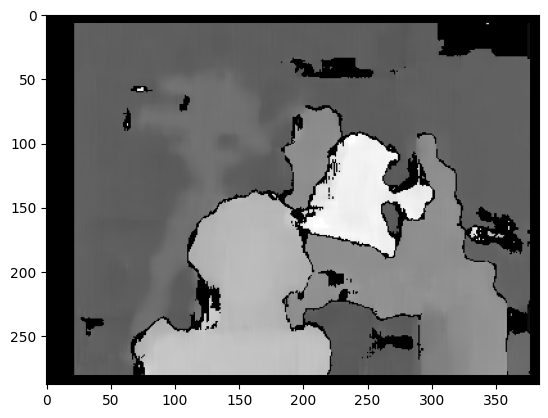

In [2]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
imgL = cv.imread('tsukuba_l.png', cv.IMREAD_GRAYSCALE)
imgR = cv.imread('tsukuba_r.png', cv.IMREAD_GRAYSCALE)
 
stereo = cv.StereoBM.create(numDisparities=16, blockSize=15)
disparity = stereo.compute(imgL,imgR)
plt.imshow(disparity,'gray')
plt.show()


O mapa de disparidade do par Tsukuba mostra claramente o princípio esperado: regiões mais claras (maior disparidade) correspondem a objetos mais próximos da câmera (a lâmpada e a estátua, em primeiro plano), enquanto regiões mais escuras (menor disparidade) correspondem ao fundo da cena, mais distante — validando o entendimento do grupo sobre a relação inversa entre disparidade e profundidade antes de aplicá-la à câmera estéreo própria.

## 3.1 Item (i) — Construção da câmera estéreo e calibração

Seguindo a referência **[1]** ("*Making A Low-Cost Stereo Camera Using OpenCV*"), a câmera estéreo do grupo foi montada com duas webcams fixadas lado a lado. O procedimento de calibração segue a seção *"Step 2: Performing stereo calibration with fixed intrinsic parameters"* da referência **[1]**, repetindo o fluxo já usado no Laboratório 4 (detecção de cantos do tabuleiro, `cv2.calibrateCamera`), mas agora aplicado às **duas câmeras simultaneamente** e complementado por `cv2.stereoCalibrate()` (que calcula a rotação **R** e translação **T** entre as duas câmeras, com os parâmetros intrínsecos individuais fixados) e `cv2.stereoRectify()` (que calcula os mapas de retificação para alinhar epipolarmente as duas imagens). Os pares de fotos do tabuleiro usados nesta etapa estão em `data/stereoL/` e `data/stereoR/` (15 pares, nomeados `frm_{i}_Paloma.jpg`).

Os parâmetros resultantes (matrizes intrínsecas `mtxL`/`mtxR`, distorções `distL`/`distR`, **R**, **T**, mapas de retificação `Left_Stereo_Map`/`Right_Stereo_Map`) são salvos no arquivo `params_py.xml`, usado nas etapas seguintes.

### Sessão 1 (`lab6/`) — script de captura + calibração fornecido pelo professor

Captura dos pares de imagens do tabuleiro (código original da aula):

In [6]:
import numpy as np
import cv2
import time

print("Checking the right and left camera IDs:")
print("Press (y) if IDs are correct and (n) to swap the IDs")
print("Press enter to start the process >> ")
input()

# Check for left and right camera IDs
CamL_id = 0
CamR_id = 2

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

for i in range(100):
    retL, frameL = CamL.read()
    retR, frameR = CamR.read()

cv2.imshow('imgL', frameL)
cv2.imshow('imgR', frameR)

# Captura a tecla uma única vez para validação
key = cv2.waitKey(0) & 0xFF
if key == ord('y') or key == ord('Y'):
    CamL_id = 0
    CamR_id = 2
    print("Camera IDs maintained")
elif key == ord('n') or key == ord('N'):
    CamL_id = 2
    CamR_id = 0
    print("Camera IDs swapped")
else:
    print("Wrong input response")
    exit(-1)

CamR.release()
CamL.release()

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)
output_path = "./data/"

# Contador de fotos salvas
count = 0

print("\n--- Pronto para capturar! ---")
print("Pressione 's' para salvar o par de fotos coloridas.")
print("Pressione 'ESC' para sair.")

while True:
    retR, frameR = CamR.read()
    retL, frameL = CamL.read()
    
    if not retR or not retL:
        print("Erro ao ler as câmeras.")
        break

    # Criando cópias para exibição (para o texto do contador não sair na foto salva)
    viewL = frameL.copy()
    viewR = frameR.copy()
    
    # Mostra o contador de fotos atual na tela de exibição
    cv2.putText(viewL, f"Fotos: {count}/15", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow('imgR', viewR)
    cv2.imshow('imgL', viewL)

    # Captura o teclado
    k = cv2.waitKey(1) & 0xFF
    
    # Se pressionar 's', salva os frames coloridos originais
    if k == ord('s'):
        # Salvando os frames originais (Coloridos)
        cv2.imwrite(f"{output_path}stereoL/frm_{count}_Paloma.jpg", frameL)
        cv2.imwrite(f"{output_path}stereoR/frm_{count}_Paloma.jpg", frameR)
        
        print(f"Foto colorida par {count} salva com sucesso!")
        count += 1
        
        # Limite máximo de fotos (15)
        if count >= 15:
            print("Limite de 15 fotos atingido!")
            break
            
    # Se pressionar ESC, fecha o programa
    elif k == 27:
        print("Fechando as câmeras pelo usuário!")
        break

# Libera as Câmeras e fecha janelas
CamR.release()
CamL.release()
cv2.destroyAllWindows()

Checking the right and left camera IDs:
Press (y) if IDs are correct and (n) to swap the IDs
Press enter to start the process >> 


Wrong input response

--- Pronto para capturar! ---
Pressione 's' para salvar o par de fotos coloridas.
Pressione 'ESC' para sair.
Foto colorida par 0 salva com sucesso!
Foto colorida par 1 salva com sucesso!
Foto colorida par 2 salva com sucesso!
Foto colorida par 3 salva com sucesso!
Foto colorida par 4 salva com sucesso!
Foto colorida par 5 salva com sucesso!
Foto colorida par 6 salva com sucesso!
Foto colorida par 7 salva com sucesso!
Foto colorida par 8 salva com sucesso!
Foto colorida par 9 salva com sucesso!
Foto colorida par 10 salva com sucesso!
Foto colorida par 11 salva com sucesso!
Foto colorida par 12 salva com sucesso!
Foto colorida par 13 salva com sucesso!
Foto colorida par 14 salva com sucesso!
Limite de 15 fotos atingido!


Calibração estéreo (script `calibrate.py` adaptado, célula 3 de `lab6/lab6_exemplo/Lab6.ipynb`):

In [7]:
import numpy as np 
import cv2
from tqdm import tqdm

# Caminho das imagens salvas pelo script anterior
pathL = "./data/stereoL/"
pathR = "./data/stereoR/"

print("Extracting image coordinates of respective 3D pattern ....\n")

# Critério de parada para o refinamento dos cantos
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# IMPORTANTE: Ajustado para o padrão (8,6) do seu primeiro script.
# Se o seu tabuleiro for diferente, mude aqui e no findChessboardCorners.
board_size = (8, 6)

objp = np.zeros((board_size[0] * board_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:board_size[0], 0:board_size[1]].T.reshape(-1, 2)

img_ptsL = []
img_ptsR = []
obj_pts = []

# Loop ajustado de 0 a 14 (para as 15 fotos tiradas)
# Se você tirou uma quantidade diferente (ex: 12), mude o 15 para o total de fotos.
total_fotos = 15

for i in tqdm(range(total_fotos)):
    # Lendo os arquivos com a nomenclatura exata do primeiro script
    filename = f"frm_{i}_Paloma.jpg"
    
    imgL = cv2.imread(pathL + filename)
    imgR = cv2.imread(pathR + filename)
    
    # Validação caso alguma foto esteja faltando ou com problemas
    if imgL is None or imgR is None:
        print(f"\n[Aviso] Arquivo {filename} não encontrado. Pulando...")
        continue

    imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    outputL = imgL.copy()
    outputR = imgR.copy()

    # Encontrando os cantos do tabuleiro (ajustado para board_size)
    retR, cornersR = cv2.findChessboardCorners(outputR, board_size, None)
    retL, cornersL = cv2.findChessboardCorners(outputL, board_size, None)

    if retR and retL:
        obj_pts.append(objp)
        cv2.cornerSubPix(imgR_gray, cornersR, (11, 11), (-1, -1), criteria)
        cv2.cornerSubPix(imgL_gray, cornersL, (11, 11), (-1, -1), criteria)
        
        cv2.drawChessboardCorners(outputR, board_size, cornersR, retR)
        cv2.drawChessboardCorners(outputL, board_size, cornersL, retL)
        
        cv2.imshow('cornersR', outputR)
        cv2.imshow('cornersL', outputL)
        
        # Pressione qualquer tecla para ir para a próxima foto do loop
        cv2.waitKey(100)  # Mudei para 100ms para passar mais rápido, se quiser manual mude para 0

        img_ptsL.append(cornersL)
        img_ptsR.append(cornersR)

cv2.destroyAllWindows()

# Garante que pelo menos algumas fotos foram detectadas antes de calibrar
if len(obj_pts) == 0:
    print("Erro: Nenhum padrão de xadrez foi encontrado nas imagens. Verifique a iluminação ou o tamanho do grid.")
    exit(-1)

print(f"\nImagens processadas com sucesso para calibração: {len(obj_pts)}/{total_fotos}")

print("Calculating left camera parameters ... ")
# Calibrating left camera
retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(obj_pts, img_ptsL, imgL_gray.shape[::-1], None, None)
hL, wL = imgL_gray.shape[:2]
new_mtxL, roiL = cv2.getOptimalNewCameraMatrix(mtxL, distL, (wL, hL), 1, (wL, hL))

print("Calculating right camera parameters ... ")
# Calibrating right camera
retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(obj_pts, img_ptsR, imgR_gray.shape[::-1], None, None)
hR, wR = imgR_gray.shape[:2]
new_mtxR, roiR = cv2.getOptimalNewCameraMatrix(mtxR, distR, (wR, hR), 1, (wR, hR))

print("Stereo calibration .....")
flags = 0
flags |= cv2.CALIB_FIX_INTRINSIC

criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Calibração estéreo
retS, new_mtxL, distL, new_mtxR, distR, Rot, Trns, Emat, Fmat = cv2.stereoCalibrate(
    obj_pts, img_ptsL, img_ptsR, new_mtxL, distL, new_mtxR, distR,
    imgL_gray.shape[::-1], criteria_stereo, flags
)

# Retificação Estéreo
rectify_scale = 1 
rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR = cv2.stereoRectify(
    new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, rectify_scale, (0, 0)
)

# Mapeamento de Retificação e Remoção de Distorção
Left_Stereo_Map = cv2.initUndistortRectifyMap(new_mtxL, distL, rect_l, proj_mat_l, imgL_gray.shape[::-1], cv2.CV_16SC2)
Right_Stereo_Map = cv2.initUndistortRectifyMap(new_mtxR, distR, rect_r, proj_mat_r, imgR_gray.shape[::-1], cv2.CV_16SC2)

print("Saving parameters ......")
cv_file = cv2.FileStorage("data/params_py.xml", cv2.FILE_STORAGE_WRITE)
cv_file.write("Left_Stereo_Map_x", Left_Stereo_Map[0])
cv_file.write("Left_Stereo_Map_y", Left_Stereo_Map[1])
cv_file.write("Right_Stereo_Map_x", Right_Stereo_Map[0])
cv_file.write("Right_Stereo_Map_y", Right_Stereo_Map[1])
cv_file.release()

print("Parâmetros salvos com sucesso em data/params_py.xml!")

Extracting image coordinates of respective 3D pattern ....



100%|███████████████████████████████████████████| 15/15 [00:01<00:00,  7.99it/s]



Imagens processadas com sucesso para calibração: 15/15
Calculating left camera parameters ... 
Calculating right camera parameters ... 
Stereo calibration .....
Saving parameters ......
Parâmetros salvos com sucesso em data/params_py.xml!


### Sessão 2 / "aula 2" (`lab6aula2/`) — versão refinada pelo grupo

Na segunda sessão, o grupo reescreveu o script de calibração com validações adicionais (checagem de detecção em ambas as câmeras simultaneamente, correção de possível *flip* de 180° na ordenação dos cantos, verificação de coerência do *baseline*) e recapturou os pares de imagens:

In [6]:
import numpy as np
import cv2
import time

print("Checking the right and left camera IDs:")
print("Press (y) if IDs are correct and (n) to swap the IDs")
print("Press enter to start the process >> ")
input()

# Check for left and right camera IDs
CamL_id = 0
CamR_id = 2

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

for i in range(100):
    retL, frameL = CamL.read()
    retR, frameR = CamR.read()

cv2.imshow('imgL', frameL)
cv2.imshow('imgR', frameR)

# Captura a tecla uma única vez para validação
key = cv2.waitKey(0) & 0xFF
if key == ord('y') or key == ord('Y'):
    CamL_id = 0
    CamR_id = 2
    print("Camera IDs maintained")
elif key == ord('n') or key == ord('N'):
    CamL_id = 2
    CamR_id = 0
    print("Camera IDs swapped")
else:
    print("Wrong input response")
    exit(-1)

CamR.release()
CamL.release()

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)
output_path = "./data/"

# Contador de fotos salvas
count = 0

print("\n--- Pronto para capturar! ---")
print("Pressione 's' para salvar o par de fotos coloridas.")
print("Pressione 'ESC' para sair.")

while True:
    retR, frameR = CamR.read()
    retL, frameL = CamL.read()
    
    if not retR or not retL:
        print("Erro ao ler as câmeras.")
        break

    # Criando cópias para exibição (para o texto do contador não sair na foto salva)
    viewL = frameL.copy()
    viewR = frameR.copy()
    
    # Mostra o contador de fotos atual na tela de exibição
    cv2.putText(viewL, f"Fotos: {count}/15", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow('imgR', viewR)
    cv2.imshow('imgL', viewL)

    # Captura o teclado
    k = cv2.waitKey(1) & 0xFF
    
    # Se pressionar 's', salva os frames coloridos originais
    if k == ord('s'):
        # Salvando os frames originais (Coloridos)
        cv2.imwrite(f"{output_path}stereoL/frm_{count}_Paloma.jpg", frameL)
        cv2.imwrite(f"{output_path}stereoR/frm_{count}_Paloma.jpg", frameR)
        
        print(f"Foto colorida par {count} salva com sucesso!")
        count += 1
        
        # Limite máximo de fotos (15)
        if count >= 15:
            print("Limite de 15 fotos atingido!")
            break
            
    # Se pressionar ESC, fecha o programa
    elif k == 27:
        print("Fechando as câmeras pelo usuário!")
        break

# Libera as Câmeras e fecha janelas
CamR.release()
CamL.release()
cv2.destroyAllWindows()

Checking the right and left camera IDs:
Press (y) if IDs are correct and (n) to swap the IDs
Press enter to start the process >> 


Wrong input response

--- Pronto para capturar! ---
Pressione 's' para salvar o par de fotos coloridas.
Pressione 'ESC' para sair.
Foto colorida par 0 salva com sucesso!
Foto colorida par 1 salva com sucesso!
Foto colorida par 2 salva com sucesso!
Foto colorida par 3 salva com sucesso!
Foto colorida par 4 salva com sucesso!
Foto colorida par 5 salva com sucesso!
Foto colorida par 6 salva com sucesso!
Foto colorida par 7 salva com sucesso!
Foto colorida par 8 salva com sucesso!
Foto colorida par 9 salva com sucesso!
Foto colorida par 10 salva com sucesso!
Foto colorida par 11 salva com sucesso!
Foto colorida par 12 salva com sucesso!
Foto colorida par 13 salva com sucesso!
Foto colorida par 14 salva com sucesso!
Limite de 15 fotos atingido!


Calibração estéreo refinada (célula 3 de `lab6aula2/lab6/lab6_exemplo/Lab6.ipynb`):

In [1]:
import os
import glob
import numpy as np 
import cv2
from tqdm import tqdm

# ==========================================
# CONFIGURAÇÕES GERAIS
# ==========================================
PATH_L = "./data/stereoL/"
PATH_R = "./data/stereoR/"
PARAMS_XML = "data/params_py.xml"

# IMPORTANTE: Ajuste para o tamanho do seu tabuleiro (cantos internos!)
CHESSBOARD = (8, 6)

# Tamanho real de cada quadrado do tabuleiro de xadrez em centímetros
SQUARE_SIZE_CM = 2.5  # Modifique para o tamanho medido com régua no seu padrão

# Tipo de nomenclatura dos arquivos. Defina como True para usar "frm_{i}_Paloma.jpg"
# ou False para usar o padrão "img{i}.png"
USA_NOMENCLATURA_PALOMA = True 

# ==========================================
# FUNÇÃO PARA EVITAR DESALINHAMENTO (FLIP)
# ==========================================
def corrigir_flip_180(corners):
    """
    Canonicaliza a ordem dos cantos do tabuleiro (resolve o flip de 180 graus).
    Garante que o primeiro canto seja o de menor (x + y) -- i.e., o mais proximo
    do canto superior-esquerdo. Aplicada de forma identica em L e R, faz o canto
    'i' da esquerda corresponder ao canto 'i' da direita.
    """
    c = corners.reshape(-1, 2)
    if (c[0, 0] + c[0, 1]) > (c[-1, 0] + c[-1, 1]):
        corners = corners[::-1].copy()
    return corners

# Teste rápido de sanidade antes de iniciar o processamento pesado
_t = np.array([[[10, 10]], [[20, 10]], [[30, 40]]], np.float32)
assert np.allclose(corrigir_flip_180(_t[::-1]).reshape(-1, 2)[0], [10, 10])
print("Teste rápido: corrigir_flip_180 OK!\n")

# Critérios de parada para o refinamento de cantos
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)

# Matriz de pontos 3D reais (Coordenadas de objeto)
objp = np.zeros((CHESSBOARD[0] * CHESSBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD[0], 0:CHESSBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE_CM  # Converte os pontos para escala física real (centímetros)

obj_pts = []  # Pontos 3D no espaço real
img_ptsL = [] # Pontos 2D na imagem Esquerda
img_ptsR = [] # Pontos 2D na imagem Direita

# Identificando as fotos salvas nas pastas
if USA_NOMENCLATURA_PALOMA:
    arquivos_esq = glob.glob(os.path.join(PATH_L, "frm_*_Paloma.jpg"))
    total_fotos = len(arquivos_esq)
else:
    arquivos_esq = glob.glob(os.path.join(PATH_L, "img*.png"))
    total_fotos = len(arquivos_esq)

print(f"Total de imagens encontradas na pasta esquerda: {total_fotos}")
print("Extraindo coordenadas dos cantos do tabuleiro...\n")

usados = 0
grayL = None
grayR = None

# Loop de processamento de imagem por imagem
for i in tqdm(range(total_fotos)):
    if USA_NOMENCLATURA_PALOMA:
        filename = f"frm_{i}_Paloma.jpg"
    else:
        filename = f"img{i+1}.png"
        
    imgL = cv2.imread(os.path.join(PATH_L, filename))
    imgR = cv2.imread(os.path.join(PATH_R, filename))
    
    # Validação caso alguma imagem falhe no carregamento
    if imgL is None or imgR is None:
        continue

    # Conversão para tons de cinza (obrigatório para detecção precisa)
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    # Cópias para exibição visual
    outputL = imgL.copy()
    outputR = imgR.copy()

    # Flags adaptativas para melhorar detecção em condições difíceis de iluminação
    flags_corners = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE

    # Encontrando os cantos do tabuleiro nas duas imagens
    retL, cornersL = cv2.findChessboardCorners(grayL, CHESSBOARD, flags_corners)
    retR, cornersR = cv2.findChessboardCorners(grayR, CHESSBOARD, flags_corners)

    # O par só é válido se o tabuleiro for detectado em AMBAS as câmeras
    if retL and retR:
        # Refina a precisão dos cantos em nível de subpixel
        cornersL = cv2.cornerSubPix(grayL, cornersL, (11, 11), (-1, -1), criteria)
        cornersR = cv2.cornerSubPix(grayR, cornersR, (11, 11), (-1, -1), criteria)
        
        # Correção crucial de ordenação para evitar desalinhamento estéreo (Flip 180°)
        cornersL = corrigir_flip_180(cornersL)
        cornersR = corrigir_flip_180(cornersR)
        
        # Armazena os pontos correspondentes
        obj_pts.append(objp)
        img_ptsL.append(cornersL)
        img_ptsR.append(cornersR)
        usados += 1

        # Desenha e exibe os cantos detectados em tempo real
        cv2.drawChessboardCorners(outputL, CHESSBOARD, cornersL, retL)
        cv2.drawChessboardCorners(outputR, CHESSBOARD, cornersR, retR)
        cv2.imshow('Cantos Esquerda (L)', outputL)
        cv2.imshow('Cantos Direita (R)', outputR)
        
        # Espera 100ms para exibição rápida. 
        cv2.waitKey(100)

cv2.destroyAllWindows()

print(f"\nPares válidos processados com sucesso: {usados}/{total_fotos}")
assert usados >= 8, "Poucos pares válidos! Capture pelo menos 8 a 15 fotos sob diferentes ângulos."

img_size = grayL.shape[::-1] # Resolução da imagem (largura, altura)

# ==========================================
# 1) CALIBRAÇÃO INTRÍNSECA INDIVIDUAL
# ==========================================
print("\nCalibrando câmera esquerda...")
retL, mtxL, distL, _, _ = cv2.calibrateCamera(obj_pts, img_ptsL, img_size, None, None)

print("Calibrando câmera direita...")
retR, mtxR, distR, _, _ = cv2.calibrateCamera(obj_pts, img_ptsR, img_size, None, None)

print(f"-> Erro de Reprojeção (RMS) Intrínseco | L: {retL:.4f} | R: {retR:.4f}")

# ==========================================
# 2) CALIBRAÇÃO ESTÉREO (Fixando parâmetros intrínsecos obtidos)
# ==========================================
print("\nCalibrando o par estéreo...")
flags_stereo = cv2.CALIB_FIX_INTRINSIC

retS, mtxL, distL, mtxR, distR, R, T, E, F = cv2.stereoCalibrate(
    obj_pts, img_ptsL, img_ptsR, mtxL, distL, mtxR, distR,
    img_size, criteria=criteria_stereo, flags=flags_stereo
)
print(f"-> RMS Estéreo obtido: {retS:.4f} (Excelente se estiver abaixo de ~1.0)")

# ==========================================
# 3) RETIFICAÇÃO ESTÉREO
# ==========================================
# Computa as matrizes de rotação e projeção para alinhar horizontalmente as linhas das imagens
rectify_scale = 1  # 1 preserva pixels pretos gerados no alinhamento; 0 corta-os fora.
R1, R2, P1, P2, Q, roiL, roiR = cv2.stereoRectify(
    mtxL, distL, mtxR, distR, img_size, R, T, alpha=rectify_scale
)

# ==========================================
# 4) GERAÇÃO DOS MAPAS DE RETIFICAÇÃO (UNDISTORT)
# ==========================================
# Cria os mapas de remapeamento de pixels pixel a pixel
Left_Stereo_Map  = cv2.initUndistortRectifyMap(mtxL, distL, R1, P1, img_size, cv2.CV_16SC2)
Right_Stereo_Map = cv2.initUndistortRectifyMap(mtxR, distR, R2, P2, img_size, cv2.CV_16SC2)

# ==========================================
# SANITY CHECKS (Verificações de coerência)
# ==========================================
baseline_cm = float(np.linalg.norm(T))
f_px = float(P1[0, 0])
print("\n=== VERIFICAÇÃO DE COERÊNCIA ===")
print(f"Baseline teórica calculada (|T|): {baseline_cm:.2f} cm")
print(f"Foco aproximado f: {f_px:.1f} px")

Tx, Ty, Tz = np.abs(T.ravel())
if Tx > Ty and Tx > Tz:
    print("✓ OK: Translação dominada pelo eixo X (Baseline Horizontal coerente).")
else:
    print("⚠ ATENÇÃO: Translação não dominada pelo eixo X! Revise a captura de imagens ou a orientação física das câmeras.")

# ==========================================
# 5) SALVAR TODOS OS PARÂMETROS EM XML
# ==========================================
print(f"\nSalvando parâmetros em: {PARAMS_XML} ...")

# Garante que a pasta de destino existe
os.makedirs(os.path.dirname(PARAMS_XML), exist_ok=True)

fs = cv2.FileStorage(PARAMS_XML, cv2.FILE_STORAGE_WRITE)

# Mapas de retificação acelerados (utilizados na função cv2.remap)
fs.write("Left_Stereo_Map_x",  Left_Stereo_Map[0])
fs.write("Left_Stereo_Map_y",  Left_Stereo_Map[1])
fs.write("Right_Stereo_Map_x", Right_Stereo_Map[0])
fs.write("Right_Stereo_Map_y", Right_Stereo_Map[1])

# Matrizes Intrínsecas e de distorção originais
fs.write("mtxL", mtxL)
fs.write("distL", distL)
fs.write("mtxR", mtxR)
fs.write("distR", distR)

# Parâmetros extrínsecos da calibração estéreo
fs.write("R", R) # Matriz de Rotação entre as câmeras
fs.write("T", T) # Vetor de Translação entre as câmeras
fs.write("Q", Q) # Matriz de reprojeção Disparidade -> Espaço 3D

# Dados métricos e de resolução
fs.write("baseline_cm", baseline_cm)
fs.write("f_px", f_px)
fs.write("img_w", img_size[0])
fs.write("img_h", img_size[1])

fs.release()
print("Calibração finalizada e salva com sucesso!")

Teste rápido: corrigir_flip_180 OK!

Total de imagens encontradas na pasta esquerda: 15
Extraindo coordenadas dos cantos do tabuleiro...



  0%|                                                    | 0/15 [00:00<?, ?it/s]Warning: Ignoring XDG_SESSION_TYPE=wayland on Gnome. Use QT_QPA_PLATFORM=wayland to run on Wayland anyway.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.


Pares válidos processados com sucesso: 15/15

Calibrando câmera esquerda...
Calibrando câmera direita...
-> Erro de Reprojeção (RMS) Intrínseco | L: 0.2080 | R: 0.2161

Calibrando o par estéreo...
-> RMS Estéreo obtido: 1.8971 (Excelente se estiver abaixo de ~1.0)

=== VERIFICAÇÃO DE COERÊNCIA ===
Baseline teórica calculada (|T|): 6.82 cm
Foco aproximado f: 574.6 px
✓ OK: Translação dominada pelo eixo X (Baseline Horizontal coerente).

Salvando parâmetros em: data/params_py.xml ...
Calibração finalizada e salva com sucesso!


### Verificação do alinhamento epipolar

Após a retificação, o grupo verificou visualmente se o alinhamento epipolar estava correto: pontos correspondentes do tabuleiro nas imagens esquerda e direita devem cair sobre a mesma linha horizontal. A célula abaixo (sessão 2) carrega os mapas de retificação salvos em `params_py.xml`, aplica-os a um par de imagens de teste e desenha linhas horizontais de referência sobre o par lado a lado:

[+] Carregando mapas de retificação de: data/params_py.xml


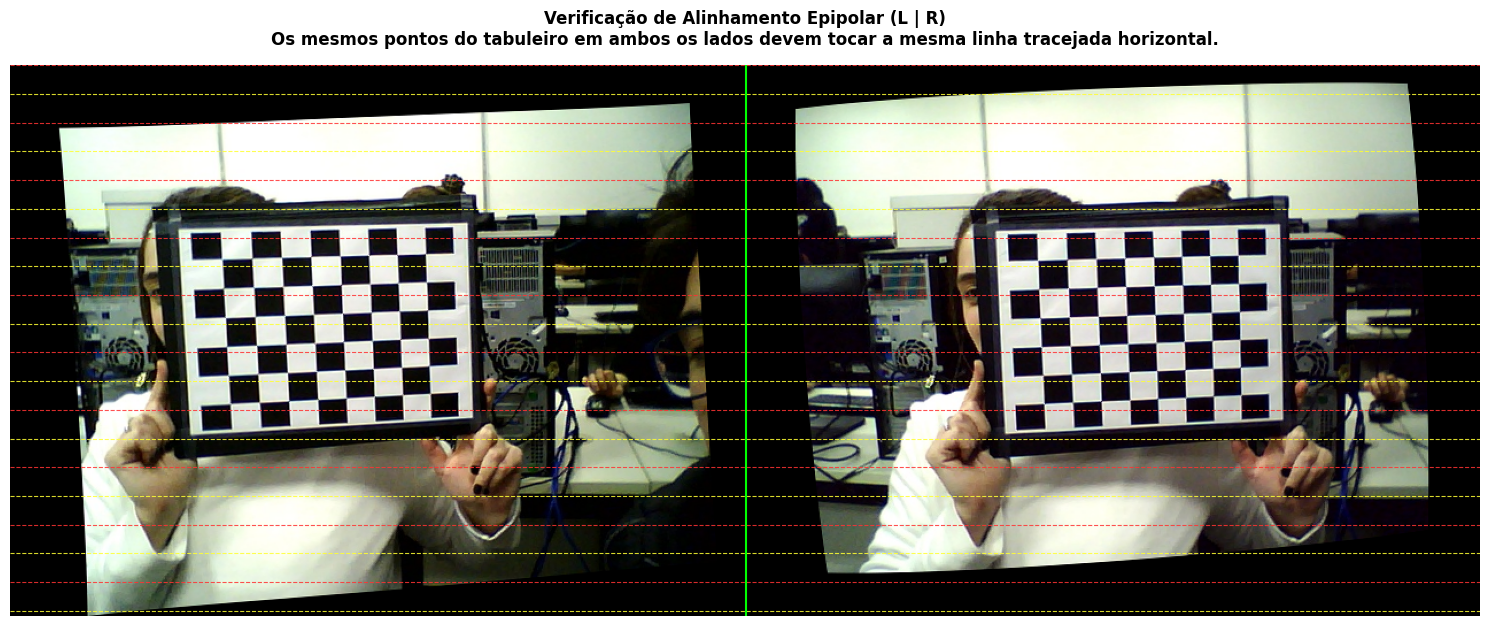

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def conferir_alinhamento_epipolar_xml(path_L, path_r, params_xml_path, nome_arquivo="frm_0_Paloma.jpg"):
    """
    Carrega os mapas de retificação diretamente do arquivo XML gerado na calibração,
    aplica nas imagens salvas em disco e plota a checagem epipolar com linhas de contraste alternadas.
    """
    # 1. Verifica se o arquivo XML de calibração existe
    if not os.path.exists(params_xml_path):
        print(f"[-] Erro: O arquivo de calibração '{params_xml_path}' não foi encontrado.")
        print("    Execute a etapa de calibração primeiro para gerar este arquivo!")
        return

    # 2. Carrega os mapas diretamente do XML
    print(f"[+] Carregando mapas de retificação de: {params_xml_path}")
    cv_file = cv2.FileStorage(params_xml_path, cv2.FILE_STORAGE_READ)
    map_L_x = cv_file.getNode("Left_Stereo_Map_x").mat()
    map_L_y = cv_file.getNode("Left_Stereo_Map_y").mat()
    map_R_x = cv_file.getNode("Right_Stereo_Map_x").mat()
    map_R_y = cv_file.getNode("Right_Stereo_Map_y").mat()
    cv_file.release()

    # 3. Carrega as imagens de teste
    imgL = cv2.imread(os.path.join(path_L, nome_arquivo))
    imgR = cv2.imread(os.path.join(path_r, nome_arquivo))
    
    if imgL is None or imgR is None:
        print(f"[-] Erro: Não foi possível carregar as imagens de teste '{nome_arquivo}' em {path_L} ou {path_r}.")
        return

    # 4. Aplica a retificação estéreo
    rect_L = cv2.remap(imgL, map_L_x, map_L_y, cv2.INTER_CUBIC)
    rect_R = cv2.remap(imgR, map_R_x, map_R_y, cv2.INTER_CUBIC)
    
    # Converte para RGB para exibição correta no Matplotlib
    rect_L_rgb = cv2.cvtColor(rect_L, cv2.COLOR_BGR2RGB)
    rect_R_rgb = cv2.cvtColor(rect_R, cv2.COLOR_BGR2RGB)
    
    # 5. Monta o painel de comparação lado a lado
    visualizacao_par = np.hstack([rect_L_rgb, rect_R_rgb])
    h, w, _ = visualizacao_par.shape
    
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.imshow(visualizacao_par)
    
    # Traça as linhas epipolares pontilhadas com cores alternadas para alto contraste
    passo_linhas = 25  
    for y in range(0, h, passo_linhas):
        cor_linha = '#FF3333' if (y // passo_linhas) % 2 == 0 else '#FFFF33'
        ax.axhline(y=y, color=cor_linha, linestyle='--', linewidth=0.8, alpha=0.85)
        
    # Divisória vertical central (marca a transição da câmera Esquerda para a Direita)
    ax.axvline(x=w//2, color='#00FF00', linestyle='-', linewidth=1.5)
    
    ax.set_title("Verificação de Alinhamento Epipolar (L | R)\n"
                 "Os mesmos pontos do tabuleiro em ambos os lados devem tocar a mesma linha tracejada horizontal.",
                 fontsize=12, fontweight='bold', pad=15)
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- Execução direta e segura (Defina as mesmas variáveis do seu script principal) ---
PATH_L = "./data/stereoL/"
PATH_R = "./data/stereoR/"
PARAMS_XML = "data/params_py.xml"

# Roda o teste lendo os dados salvos, sem depender de variáveis soltas na memória
conferir_alinhamento_epipolar_xml(PATH_L, PATH_R, PARAMS_XML, nome_arquivo="frm_0_Paloma.jpg")

### Discussão dos resultados — Item (i)

Os dois procedimentos de calibração (sessão 1 e sessão 2) produziram parâmetros numericamente distintos, como esperado — a câmera estéreo foi desmontada e remontada entre as aulas, alterando ligeiramente a geometria física (baseline, ângulo relativo entre as câmeras). Na **sessão 2**, o grupo registrou explicitamente as métricas de qualidade da calibração:

- **Erro de reprojeção intrínseco (RMS):** 0,208 px (câmera esquerda) e 0,216 px (câmera direita) — ambos sub-pixel, indicando boa detecção de cantos;
- **RMS da calibração estéreo:** 1,897 px — acima do valor "excelente" (< 1,0 px) citado no próprio código, sugerindo que, embora aceitável, o par ainda apresenta alguma imprecisão no alinhamento conjunto (possivelmente por pequenas vibrações entre a captura dos pares L/R, já que as duas câmeras não capturam de forma perfeitamente síncrona);
- **Baseline calculado (|T|):** 6,82 cm — coerente com a distância física medida entre os centros ópticos das duas webcams no suporte;
- **Foco aproximado:** 574,6 px;
- A translação entre as câmeras foi corretamente dominada pelo eixo X, confirmando que as câmeras estão de fato dispostas lado a lado horizontalmente (e não verticalmente ou rotacionadas), como o experimento pressupõe.

A verificação epipolar (imagem acima) mostra as linhas tracejadas horizontais cruzando os mesmos pontos do tabuleiro em ambas as metades da imagem (esquerda e direita), confirmando visualmente que a retificação está funcionando corretamente — pré-requisito indispensável para que o *Block Matching* (item ii) busque correspondências apenas ao longo de cada linha horizontal.

## 3.2 Item (ii) — Mapa de disparidade com *Block Matching*

Seguindo a seção *"Block Matching For Dense Stereo Correspondence"* da referência **[3]**, o grupo implementou (`disparity_params_gui.py`, adaptado para ler `params_py.xml`) uma interface de sintonia dos parâmetros do `cv2.StereoBM`, com *trackbars* interativas (`numDisparities`, `blockSize`, `preFilterType`, `preFilterSize`, `preFilterCap`, `textureThreshold`, `uniquenessRatio`, `speckleRange`, `speckleWindowSize`, `disp12MaxDiff`, `minDisparity`) sobre o vídeo ao vivo das duas câmeras já retificadas. Ao final, os parâmetros escolhidos são salvos em `depth_estimation_params_py.xml`.

### Sessão 2 — versão refinada (classe `StereoTuner`)

Na sessão 2, o grupo estruturou a sintonia em duas etapas: **(a)** um "mosaico" automático 3×3 testando combinações de `numDisparities`×`blockSize` e recomendando o quadrante com melhor equilíbrio entre densidade e nitidez do mapa, usado como ponto de partida; **(b)** a sintonia fina ao vivo, com as *trackbars* sobre o vídeo real das câmeras retificadas.

[INFO] Conectando ao barramento das câmeras físicas...
[INFO] Captura em tempo real bem-sucedida e cache atualizado.

[INFO] Computando matriz de varredura paramétrica reduzida...


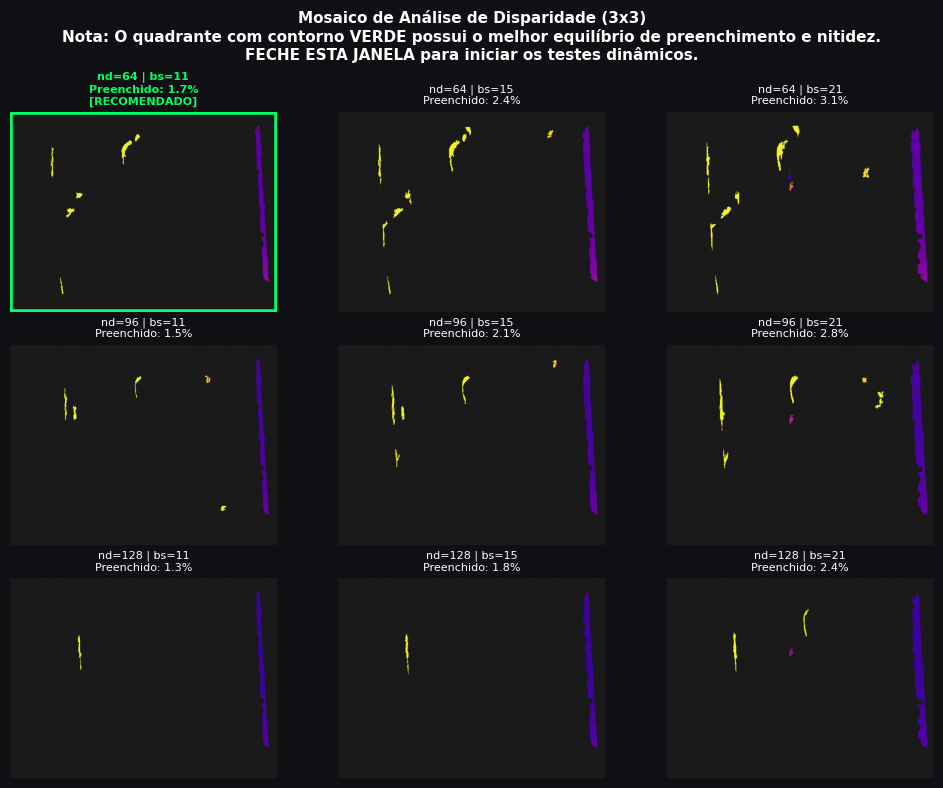


          SINTONIA FINA DE PROFUNDIDADE EM TEMPO REAL
[INFO] Monitoramento ao vivo ativado.
    > Pressione [ESC] para consolidar e salvar as configurações no XML.

[INFO] Gravando os parâmetros otimizados no arquivo XML final...
[INFO] Configurações persistidas com sucesso em: ./data/depth_estmation_params_py.xml


In [3]:
import os
import sys
import numpy as np 
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =====================================================================
# CONFIGURAÇÕES DA ARQUITETURA
# =====================================================================
class StereoConfig:
    DATA_DIR = "./data"
    PARAMS_XML = os.path.join(DATA_DIR, "params_py.xml")
    DEPTH_PARAMS_XML = os.path.join(DATA_DIR, "depth_estmation_params_py.xml")
    
    CAM_L_ID = 2
    CAM_R_ID = 0
    FRAME_W = 640
    FRAME_H = 480

    # Configurações iniciais refinadas
    DEFAULT_PARAMS = {
        "numDisparities": 64,
        "blockSize": 15,
        "minDisparity": 0,
        "uniquenessRatio": 10,
        "speckleWindowSize": 100,
        "speckleRange": 2,
        "disp12MaxDiff": 5,
        "preFilterCap": 31,
        "preFilterSize": 5,
        "preFilterType": 1,
        "textureThreshold": 10
    }


# =====================================================================
# MOTOR DE PROCESSAMENTO E SINTONIA ESTÉREO
# =====================================================================
class StereoTuner:
    def __init__(self):
        self.config = StereoConfig()
        self.Ln = None
        self.Rn = None
        self.Lx = None
        self.Ly = None
        self.Rx = None
        self.Ry = None
        
        # Variáveis de controle para a seleção interativa
        self.selected_nd = self.config.DEFAULT_PARAMS["numDisparities"]
        self.selected_bs = self.config.DEFAULT_PARAMS["blockSize"]

    def inicializar_recursos(self) -> bool:
        """Carrega calibração estéreo e prepara as imagens de teste."""
        os.makedirs(self.config.DATA_DIR, exist_ok=True)
        par_L_path = os.path.join(self.config.DATA_DIR, "sintonia_L.png")
        par_R_path = os.path.join(self.config.DATA_DIR, "sintonia_R.png")

        if not os.path.exists(self.config.PARAMS_XML):
            print(f"[ERRO] Calibração inexistente em {self.config.PARAMS_XML}")
            return False

        # Leitura segura das matrizes de calibração estéreo
        fs = cv2.FileStorage(self.config.PARAMS_XML, cv2.FILE_STORAGE_READ)
        self.Lx = fs.getNode("Left_Stereo_Map_x").mat()
        self.Ly = fs.getNode("Left_Stereo_Map_y").mat()
        self.Rx = fs.getNode("Right_Stereo_Map_x").mat()
        self.Ry = fs.getNode("Right_Stereo_Map_y").mat()
        fs.release()

        # Fluxo de captura inteligente
        try:
            print("[INFO] Conectando ao barramento das câmeras físicas...")
            cam_L = cv2.VideoCapture(self.config.CAM_L_ID)
            cam_R = cv2.VideoCapture(self.config.CAM_R_ID)
            
            for cam in (cam_L, cam_R):
                cam.set(cv2.CAP_PROP_FRAME_WIDTH, self.config.FRAME_W)
                cam.set(cv2.CAP_PROP_FRAME_HEIGHT, self.config.FRAME_H)

            # Esvazia buffers obsoletos para estabilização de luz
            for _ in range(20):
                cam_L.grab()
                cam_R.grab()

            ok_L, frame_L = cam_L.read()
            ok_R, frame_R = cam_R.read()
            cam_L.release()
            cam_R.release()

            if ok_L and ok_R:
                gray_L = cv2.cvtColor(frame_L, cv2.COLOR_BGR2GRAY)
                gray_R = cv2.cvtColor(frame_R, cv2.COLOR_BGR2GRAY)
                
                # Remapeamento com interpolação Lanczos4 para máxima fidelidade geométrica
                self.Ln = cv2.remap(gray_L, self.Lx, self.Ly, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
                self.Rn = cv2.remap(gray_R, self.Rx, self.Ry, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
                
                cv2.imwrite(par_L_path, self.Ln)
                cv2.imwrite(par_R_path, self.Rn)
                print("[INFO] Captura em tempo real bem-sucedida e cache atualizado.")
        except Exception as e:
            print(f"[AVISO] Câmeras indisponíveis ({e}). Utilizando cache persistido do disco.")

        if self.Ln is None or self.Rn is None:
            if os.path.exists(par_L_path) and os.path.exists(par_R_path):
                self.Ln = cv2.imread(par_L_path, cv2.IMREAD_GRAYSCALE)
                self.Rn = cv2.imread(par_R_path, cv2.IMREAD_GRAYSCALE)
                print("[INFO] Par estático recuperado do disco com sucesso.")
            else:
                print("[ERRO] Sem cache em disco e sem dispositivos de câmera ativos.")
                return False
        return True

    def calcular_disparidade(self, params_dict: dict) -> tuple:
        """Calcula a disparidade aplicando restrições matemáticas e formatação limpa."""
        nd = max(16, (int(params_dict["numDisparities"]) // 16) * 16)
        bs = int(params_dict["blockSize"]) | 1  # Força tamanho ímpar

        stereo = cv2.StereoBM_create(numDisparities=nd, blockSize=bs)
        stereo.setMinDisparity(int(params_dict["minDisparity"]))
        stereo.setUniquenessRatio(int(params_dict["uniquenessRatio"]))
        stereo.setSpeckleWindowSize(int(params_dict["speckleWindowSize"]))
        stereo.setSpeckleRange(int(params_dict["speckleRange"]))
        stereo.setDisp12MaxDiff(int(params_dict["disp12MaxDiff"]))
        stereo.setPreFilterCap(max(1, int(params_dict["preFilterCap"])))
        stereo.setPreFilterSize(int(params_dict["preFilterSize"]) | 1)
        stereo.setPreFilterType(int(params_dict["preFilterType"]))
        stereo.setTextureThreshold(int(params_dict["textureThreshold"]))

        raw_disp = stereo.compute(self.Ln, self.Rn).astype(np.float32) / 16.0
        
        # Filtro de Limpeza: isola buracos de oclusão (valores nulos ou negativos)
        mask_invalida = raw_disp <= params_dict["minDisparity"]
        
        normalized_disp = (raw_disp - int(params_dict["minDisparity"])) / nd
        normalized_disp[mask_invalida] = np.nan  # Transforma o ruído em NaN para tratamento no colormap
        
        return normalized_disp, nd, bs

    def avaliar_qualidade_mapa(self, disp_map: np.ndarray) -> float:
        """Avalia estatisticamente a disparidade baseando-se em densidade e nitidez estrutural."""
        valid_mask = ~np.isnan(disp_map)
        densidade = np.mean(valid_mask)
        
        if densidade < 0.1:
            return 0.0
            
        clean_temp = np.nan_to_num(disp_map, nan=0.0)
        nitidez = cv2.Laplacian(clean_temp, cv2.CV_32F).var()
        
        # Score balanceado (80% peso para cobertura, 20% para detalhes sem ruído)
        return (densidade * 0.8) + (min(nitidez * 10, 1.0) * 0.2)

    def executar_mosaico_interativo(self):
        """Renderiza as opções estáticas em uma matriz reduzida (3x3)."""
        print("\n[INFO] Computando matriz de varredura paramétrica reduzida...")
        
        # Matriz reduzida para 3 opções de cada parâmetro (total 9 quadrantes)
        nd_candidates = [64, 96, 128]
        bs_candidates = [11, 15, 21]

        fig, axes = plt.subplots(len(nd_candidates), len(bs_candidates), figsize=(10, 8))
        
        melhor_score = -1.0
        melhor_coord = (0, 0)
        dados_mosaico = {}

        # Configura o colormap para que valores NaN fiquem cinza-escuro neutro
        cmap_atual = plt.cm.plasma.copy()
        cmap_atual.set_bad(color='#1A1A1A')

        for i, nd in enumerate(nd_candidates):
            for j, bs in enumerate(bs_candidates):
                cfg = dict(self.config.DEFAULT_PARAMS)
                cfg["numDisparities"] = nd
                cfg["blockSize"] = bs
                
                disp, nd_real, bs_real = self.calcular_disparidade(cfg)
                score = self.avaliar_qualidade_mapa(disp)
                
                dados_mosaico[(i, j)] = (nd_real, bs_real)
                
                ax = axes[i, j]
                ax.imshow(disp, cmap=cmap_atual, vmin=0.0, vmax=1.0)
                ax.axis("off")
                
                taxa_preenchida = np.count_nonzero(~np.isnan(disp)) / disp.size * 100
                ax.set_title(f"nd={nd_real} | bs={bs_real}\nPreenchido: {taxa_preenchida:.1f}%", fontsize=8, color='white')
                
                # Armazena o melhor resultado sob a perspectiva do algoritmo
                if score > melhor_score:
                    melhor_score = score
                    melhor_coord = (i, j)

        # Destaca o quadrante recomendado pelo computador com uma borda verde
        vencedor_ax = axes[melhor_coord[0], melhor_coord[1]]
        rect = Rectangle((0, 0), vencedor_ax.get_xlim()[1], vencedor_ax.get_ylim()[0], 
                         linewidth=4, edgecolor='#00FF66', facecolor='none', transform=vencedor_ax.transData)
        vencedor_ax.add_patch(rect)
        vencedor_ax.set_title(vencedor_ax.get_title() + "\n[RECOMENDADO]", fontsize=8, color='#00FF66', fontweight='bold')

        fig.patch.set_facecolor('#0F0F14')
        plt.suptitle("Mosaico de Análise de Disparidade (3x3)\n"
                     "Nota: O quadrante com contorno VERDE possui o melhor equilíbrio de preenchimento e nitidez.\n"
                     "FECHE ESTA JANELA para iniciar os testes dinâmicos.", 
                     fontsize=11, fontweight='bold', color='white', y=0.98)
        
        plt.tight_layout()
        
        # Define os parâmetros de partida com base na recomendação automática
        self.selected_nd, self.selected_bs = dados_mosaico[melhor_coord]
        plt.show()

    def sintonizar_ao_vivo(self):
        """Abre a câmera física e aplica as trackbars dinâmicas do OpenCV."""
        print("\n" + "="*60)
        print("          SINTONIA FINA DE PROFUNDIDADE EM TEMPO REAL")
        print("="*60)
        
        def null_callback(x): pass

        window_name = 'Painel Estereo'

        # Criação e inicialização da janela
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
        cv2.resizeWindow(window_name, 800, 750)
        
        # Força o processamento de eventos da GUI para garantir a criação da janela física
        cv2.startWindowThread() 
        cv2.waitKey(100)  

        # Inicializa os sliders com segurança na janela
        try:
            cv2.createTrackbar('numDisparities',   window_name, int(self.selected_nd // 16), 17,  null_callback)
            cv2.createTrackbar('blockSize',        window_name, int((self.selected_bs - 5) // 2), 50,  null_callback)
            cv2.createTrackbar('preFilterType',    window_name, self.config.DEFAULT_PARAMS["preFilterType"],  1,   null_callback)
            cv2.createTrackbar('preFilterSize',    window_name, int((self.config.DEFAULT_PARAMS["preFilterSize"] - 5) // 2),  25,  null_callback)
            cv2.createTrackbar('preFilterCap',     window_name, self.config.DEFAULT_PARAMS["preFilterCap"],  62,  null_callback)
            cv2.createTrackbar('textureThreshold', window_name, self.config.DEFAULT_PARAMS["textureThreshold"], 100, null_callback)
            cv2.createTrackbar('uniquenessRatio',  window_name, self.config.DEFAULT_PARAMS["uniquenessRatio"], 100, null_callback)
            cv2.createTrackbar('speckleRange',     window_name, self.config.DEFAULT_PARAMS["speckleRange"],  100, null_callback)
            cv2.createTrackbar('speckleWindowSize',window_name, int(self.config.DEFAULT_PARAMS["speckleWindowSize"] // 2),  25,  null_callback)
            cv2.createTrackbar('disp12MaxDiff',    window_name, self.config.DEFAULT_PARAMS["disp12MaxDiff"],  25,  null_callback)
            cv2.createTrackbar('minDisparity',     window_name, self.config.DEFAULT_PARAMS["minDisparity"],  25,  null_callback)
        except cv2.error as e:
            print(f"[ERRO] Erro crítico ao criar Trackbars: {e}")
            print("Certifique-se de que seu ambiente possui suporte a janelas gráficas ativo.")
            return

        cam_L = cv2.VideoCapture(self.config.CAM_L_ID)
        cam_R = cv2.VideoCapture(self.config.CAM_R_ID)
        
        stereo = cv2.StereoBM_create()

        print("[INFO] Monitoramento ao vivo ativado.")
        print("    > Pressione [ESC] para consolidar e salvar as configurações no XML.")

        while True:
            ok_L, frame_L = cam_L.read()
            ok_R, frame_R = cam_R.read()

            if ok_L and ok_R:
                gray_L = cv2.cvtColor(frame_L, cv2.COLOR_BGR2GRAY)
                gray_R = cv2.cvtColor(frame_R, cv2.COLOR_BGR2GRAY)

                # Alinhamento epipolar em tempo real utilizando mapas calibrados
                nice_L = cv2.remap(gray_L, self.Lx, self.Ly, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
                nice_R = cv2.remap(gray_R, self.Rx, self.Ry, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

                # Leitura segura das variáveis ajustadas pelo usuário
                numDisparities    = cv2.getTrackbarPos('numDisparities',    window_name) * 16
                blockSize         = cv2.getTrackbarPos('blockSize',         window_name) * 2 + 5
                preFilterType     = cv2.getTrackbarPos('preFilterType',     window_name)
                preFilterSize     = cv2.getTrackbarPos('preFilterSize',     window_name) * 2 + 5
                preFilterCap      = cv2.getTrackbarPos('preFilterCap',      window_name)
                textureThreshold  = cv2.getTrackbarPos('textureThreshold',  window_name)
                uniquenessRatio   = cv2.getTrackbarPos('uniquenessRatio',   window_name)
                speckleRange      = cv2.getTrackbarPos('speckleRange',      window_name)
                speckleWindowSize = cv2.getTrackbarPos('speckleWindowSize', window_name) * 2
                disp12MaxDiff     = cv2.getTrackbarPos('disp12MaxDiff',     window_name)
                minDisparity      = cv2.getTrackbarPos('minDisparity',      window_name)

                if numDisparities <= 0:
                    numDisparities = 16

                # Aplicação dos novos estados no pipeline OpenCV
                stereo.setNumDisparities(numDisparities)
                stereo.setBlockSize(blockSize)
                stereo.setPreFilterType(preFilterType)
                stereo.setPreFilterSize(preFilterSize)
                stereo.setPreFilterCap(max(1, preFilterCap))
                stereo.setTextureThreshold(textureThreshold)
                stereo.setUniquenessRatio(uniquenessRatio)
                stereo.setSpeckleRange(speckleRange)
                stereo.setSpeckleWindowSize(speckleWindowSize)
                stereo.setDisp12MaxDiff(disp12MaxDiff)
                stereo.setMinDisparity(minDisparity)

                # Computação e normalização para visualização
                disparity = stereo.compute(nice_L, nice_R).astype(np.float32)
                disparity = (disparity / 16.0 - minDisparity) / numDisparities

                # Renderiza o mapa térmico (JET)
                disparity_color = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
                disparity_color = cv2.applyColorMap(disparity_color, cv2.COLORMAP_JET)

                cv2.imshow(window_name, disparity_color)

                if cv2.waitKey(1) & 0xFF == 27:  # Sair com ESC
                    break
            else:
                # Recuperação de conexões instáveis de hardware
                cam_L = cv2.VideoCapture(self.config.CAM_L_ID)
                cam_R = cv2.VideoCapture(self.config.CAM_R_ID)

        cam_L.release()
        cam_R.release()
        cv2.destroyAllWindows()
        
        for _ in range(5):
            cv2.waitKey(1)

        # =====================================================================
        # PERSISTÊNCIA DOS PARÂMETROS FINAIS
        # =====================================================================
        print("\n[INFO] Gravando os parâmetros otimizados no arquivo XML final...")
        os.makedirs(os.path.dirname(self.config.DEPTH_PARAMS_XML), exist_ok=True)
        fs_write = cv2.FileStorage(self.config.DEPTH_PARAMS_XML, cv2.FILE_STORAGE_WRITE)
        
        if fs_write.isOpened():
            fs_write.write("numDisparities", numDisparities)
            fs_write.write("blockSize", blockSize)
            fs_write.write("preFilterType", preFilterType)
            fs_write.write("preFilterSize", preFilterSize)
            fs_write.write("preFilterCap", preFilterCap)
            fs_write.write("textureThreshold", textureThreshold)
            fs_write.write("uniquenessRatio", uniquenessRatio)
            fs_write.write("speckleRange", speckleRange)
            fs_write.write("speckleWindowSize", speckleWindowSize)
            fs_write.write("disp12MaxDiff", disp12MaxDiff)
            fs_write.write("minDisparity", minDisparity)
            fs_write.write("M", 39.075)
            fs_write.release()
            print(f"[INFO] Configurações persistidas com sucesso em: {self.config.DEPTH_PARAMS_XML}")
        else:
            print("[ERRO] Falha ao abrir o arquivo XML para escrita.")


# =====================================================================
# INICIALIZAÇÃO DO PROGRAMA
# =====================================================================
if __name__ == "__main__":
    tuner = StereoTuner()
    if tuner.inicializar_recursos():
        tuner.executar_mosaico_interativo()
        tuner.sintonizar_ao_vivo()
    else:
        print("[ERRO] Execução abortada devido a falha crítica nos recursos de hardware ou calibração.")
        sys.exit(-1)

O mosaico acima (gerado automaticamente) resume visualmente o efeito de `numDisparities` e `blockSize` sobre a densidade do mapa de disparidade — o quadrante destacado em verde foi o recomendado pelo próprio script como ponto de partida para a sintonia manual seguinte, feita ao vivo com as *trackbars*.

### Sessão 1 — versão inicial fornecida pelo professor

In [2]:
import numpy as np 
import cv2
import os

# Check for left and right camera IDs
# These values can change depending on the system
CamL_id = 2 # Camera ID for left camera
CamR_id = 0 # Camera ID for right camera

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

# Reading the mapping values for stereo image rectification
cv_file = cv2.FileStorage("data/params_py.xml", cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
cv_file.release()

def nothing(x):
    pass

cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 600, 600)

cv2.createTrackbar('numDisparities','disp',1,17,nothing)
cv2.createTrackbar('blockSize','disp',5,50,nothing)
cv2.createTrackbar('preFilterType','disp',1,1,nothing)
cv2.createTrackbar('preFilterSize','disp',2,25,nothing)
cv2.createTrackbar('preFilterCap','disp',5,62,nothing)
cv2.createTrackbar('textureThreshold','disp',10,100,nothing)
cv2.createTrackbar('uniquenessRatio','disp',15,100,nothing)
cv2.createTrackbar('speckleRange','disp',0,100,nothing)
cv2.createTrackbar('speckleWindowSize','disp',3,25,nothing)
cv2.createTrackbar('disp12MaxDiff','disp',5,25,nothing)
cv2.createTrackbar('minDisparity','disp',5,25,nothing)

# Creating an object of StereoBM algorithm
stereo = cv2.StereoBM_create()

while True:

    # Capturing and storing left and right camera images
    retL, imgL = CamL.read()
    retR, imgR = CamR.read()
    
    # Proceed only if the frames have been captured
    if retL and retR:
        imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
        imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)

        # Applying stereo image rectification on the left image
        Left_nice = cv2.remap(imgL_gray,
                            Left_Stereo_Map_x,
                            Left_Stereo_Map_y,
                            cv2.INTER_LANCZOS4,
                            cv2.BORDER_CONSTANT,
                            0)
        
        # Applying stereo image rectification on the right image
        Right_nice = cv2.remap(imgR_gray,
                            Right_Stereo_Map_x,
                            Right_Stereo_Map_y,
                            cv2.INTER_LANCZOS4,
                            cv2.BORDER_CONSTANT,
                            0)

        # Updating the parameters based on the trackbar positions
        numDisparities = cv2.getTrackbarPos('numDisparities','disp')*16
        blockSize = cv2.getTrackbarPos('blockSize','disp')*2 + 5
        preFilterType = cv2.getTrackbarPos('preFilterType','disp')
        preFilterSize = cv2.getTrackbarPos('preFilterSize','disp')*2 + 5
        preFilterCap = cv2.getTrackbarPos('preFilterCap','disp')
        textureThreshold = cv2.getTrackbarPos('textureThreshold','disp')
        uniquenessRatio = cv2.getTrackbarPos('uniquenessRatio','disp')
        speckleRange = cv2.getTrackbarPos('speckleRange','disp')
        speckleWindowSize = cv2.getTrackbarPos('speckleWindowSize','disp')*2
        disp12MaxDiff = cv2.getTrackbarPos('disp12MaxDiff','disp')
        minDisparity = cv2.getTrackbarPos('minDisparity','disp')
        
        # Setting the updated parameters before computing disparity map
        stereo.setNumDisparities(numDisparities)
        stereo.setBlockSize(blockSize)
        stereo.setPreFilterType(preFilterType)
        stereo.setPreFilterSize(preFilterSize)
        stereo.setPreFilterCap(preFilterCap)
        stereo.setTextureThreshold(textureThreshold)
        stereo.setUniquenessRatio(uniquenessRatio)
        stereo.setSpeckleRange(speckleRange)
        stereo.setSpeckleWindowSize(speckleWindowSize)
        stereo.setDisp12MaxDiff(disp12MaxDiff)
        stereo.setMinDisparity(minDisparity)

        # Calculating disparity using the StereoBM algorithm
        disparity = stereo.compute(Left_nice, Right_nice)
        
        # Converting to float32 
        disparity = disparity.astype(np.float32)

        # Scaling down the disparity values and normalizing them 
        disparity = (disparity/16.0 - minDisparity)/numDisparities

        # Displaying the disparity map
        cv2.imshow("disp", disparity)

        # Close window using esc key
        if cv2.waitKey(1) & 0xFF == 27:
            break
    
    else:
        CamL = cv2.VideoCapture(CamL_id)
        CamR = cv2.VideoCapture(CamR_id)


# ==========================================
# 1. LIBERTAR RECURSOS DAS CÂMARAS E GUI
# ==========================================
CamL.release()
CamR.release()
cv2.destroyAllWindows()

print("A guardar os parâmetros de estimativa de profundidade......")

# ==========================================
# 2. GARANTIR QUE A DIRETORIA EXISTE
# ==========================================
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "depth_estmation_params_py.xml")

# ==========================================
# 3. GUARDAR FICHEIRO XML
# ==========================================
cv_file = cv2.FileStorage(file_path, cv2.FILE_STORAGE_WRITE)

if not cv_file.isOpened():
    print(f"ERRO CRÍTICO: Não foi possível abrir o ficheiro {file_path} para escrita.")
else:
    cv_file.write("numDisparities", numDisparities)
    cv_file.write("blockSize", blockSize)
    cv_file.write("preFilterType", preFilterType)
    cv_file.write("preFilterSize", preFilterSize)
    cv_file.write("preFilterCap", preFilterCap)
    cv_file.write("textureThreshold", textureThreshold)
    cv_file.write("uniquenessRatio", uniquenessRatio)
    cv_file.write("speckleRange", speckleRange)
    cv_file.write("speckleWindowSize", speckleWindowSize)
    cv_file.write("disp12MaxDiff", disp12MaxDiff)
    cv_file.write("minDisparity", minDisparity)
    cv_file.write("M", 39.075)
    cv_file.release()
    print("Parâmetros guardados com sucesso!")

QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font 

A guardar os parâmetros de estimativa de profundidade......
Parâmetros guardados com sucesso!


In [3]:
import numpy as np 
import cv2
import os

# Check for left and right camera IDs
CamL_id = 2 # Camera ID for left camera
CamR_id = 0 # Camera ID for right camera

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

# Reading the mapping values for stereo image rectification
cv_file = cv2.FileStorage("data/params_py.xml", cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
cv_file.release()

# Reading the stored StereoBM parameters (incluindo o M calibrado anteriormente)
cv_file = cv2.FileStorage("../data/depth_estmation_params_py.xml", cv2.FILE_STORAGE_READ)
numDisparities = int(cv_file.getNode("numDisparities").real())
blockSize = int(cv_file.getNode("blockSize").real())
preFilterType = int(cv_file.getNode("preFilterType").real())
preFilterSize = int(cv_file.getNode("preFilterSize").real())
preFilterCap = int(cv_file.getNode("preFilterCap").real())
textureThreshold = int(cv_file.getNode("textureThreshold").real())
uniquenessRatio = int(cv_file.getNode("uniquenessRatio").real())
speckleRange = int(cv_file.getNode("speckleRange").real())
speckleWindowSize = int(cv_file.getNode("speckleWindowSize").real())
disp12MaxDiff = int(cv_file.getNode("disp12MaxDiff").real())
minDisparity = int(cv_file.getNode("minDisparity").real())
M = cv_file.getNode("M").real() # Mantemos o valor de M intacto
cv_file.release()

def nothing(x):
    pass

cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 600, 600)
cv2.namedWindow('left image', cv2.WINDOW_NORMAL)
cv2.resizeWindow('left image', 600, 600)

cv2.createTrackbar('numDisparities','disp', int(numDisparities/16), 17, nothing)
cv2.createTrackbar('blockSize','disp', int((blockSize-5)/2), 50, nothing)
cv2.createTrackbar('preFilterType','disp', preFilterType, 1, nothing)
cv2.createTrackbar('preFilterSize','disp', int((preFilterSize-5)/2), 25, nothing)
cv2.createTrackbar('preFilterCap','disp', preFilterCap, 62, nothing)
cv2.createTrackbar('textureThreshold','disp', textureThreshold, 100, nothing)
cv2.createTrackbar('uniquenessRatio','disp', uniquenessRatio, 100, nothing)
cv2.createTrackbar('speckleRange','disp', speckleRange, 100, nothing)
cv2.createTrackbar('speckleWindowSize','disp', int(speckleWindowSize/2), 25, nothing)
cv2.createTrackbar('disp12MaxDiff','disp', disp12MaxDiff, 25, nothing)
cv2.createTrackbar('minDisparity','disp', minDisparity, 25, nothing)

# Creating an object of StereoBM algorithm
stereo = cv2.StereoBM_create()

# Flag de controle para salvar ou não
salvar_parametros = False

while True:
    # Capturing and storing left and right camera images
    retR, imgR = CamR.read()
    retL, imgL = CamL.read()
    
    if retL and retR:
        imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
        imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)

        # Applying stereo image rectification
        Left_nice = cv2.remap(imgL_gray, Left_Stereo_Map_x, Left_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
        Right_nice = cv2.remap(imgR_gray, Right_Stereo_Map_x, Right_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

        # Updating the parameters based on the trackbar positions
        numDisparities = cv2.getTrackbarPos('numDisparities','disp')*16
        blockSize = cv2.getTrackbarPos('blockSize','disp')*2 + 5
        preFilterType = cv2.getTrackbarPos('preFilterType','disp')
        preFilterSize = cv2.getTrackbarPos('preFilterSize','disp')*2 + 5
        preFilterCap = cv2.getTrackbarPos('preFilterCap','disp')
        textureThreshold = cv2.getTrackbarPos('textureThreshold','disp')
        uniquenessRatio = cv2.getTrackbarPos('uniquenessRatio','disp')
        speckleRange = cv2.getTrackbarPos('speckleRange','disp')
        speckleWindowSize = cv2.getTrackbarPos('speckleWindowSize','disp')*2
        disp12MaxDiff = cv2.getTrackbarPos('disp12MaxDiff','disp')
        minDisparity = cv2.getTrackbarPos('minDisparity','disp')
        
        # Setting the updated parameters
        stereo.setNumDisparities(numDisparities)
        stereo.setBlockSize(blockSize)
        stereo.setPreFilterType(preFilterType)
        stereo.setPreFilterSize(preFilterSize)
        stereo.setPreFilterCap(preFilterCap)
        stereo.setTextureThreshold(textureThreshold)
        stereo.setUniquenessRatio(uniquenessRatio)
        stereo.setSpeckleRange(speckleRange)
        stereo.setSpeckleWindowSize(speckleWindowSize)
        stereo.setDisp12MaxDiff(disp12MaxDiff)
        stereo.setMinDisparity(minDisparity)

        # Calculating disparity
        disparity = stereo.compute(Left_nice, Right_nice)
        
        disparity = disparity.astype(np.float32)
        disparity = (disparity/16.0 - minDisparity)/numDisparities

        cv2.imshow("disp", disparity)
        cv2.imshow("left image", imgL)

        # Captura de Teclas
        key = cv2.waitKey(1) & 0xFF
        
        if key == 27: # Tecla ESC pressionada
            print("ESC pressionado. Saindo SEM salvar...")
            salvar_parametros = False
            break
        elif key == ord('s') or key == ord('S'): # Tecla 'S' pressionada
            print("'S' pressionado. Iniciando salvamento...")
            salvar_parametros = True
            break
    else:
        CamL = cv2.VideoCapture(CamL_id)
        CamR = cv2.VideoCapture(CamR_id)

# ==========================================
# 1. LIBERAR RECURSOS
# ==========================================
CamL.release()
CamR.release()
cv2.destroyAllWindows()

# ==========================================
# 2. SALVAR DADOS (SE 'S' FOI PRESSIONADO)
# ==========================================
if salvar_parametros:
    output_dir = "../data"
    os.makedirs(output_dir, exist_ok=True)
    
    cv_file = cv2.FileStorage(f"{output_dir}/depth_estmation_params_py.xml", cv2.FILE_STORAGE_WRITE)
    if not cv_file.isOpened():
        print(f"ERRO CRÍTICO: Não foi possível abrir o arquivo para escrita no diretório {output_dir}")
    else:
        cv_file.write("numDisparities", numDisparities)
        cv_file.write("blockSize", blockSize)
        cv_file.write("preFilterType", preFilterType)
        cv_file.write("preFilterSize", preFilterSize)
        cv_file.write("preFilterCap", preFilterCap)
        cv_file.write("textureThreshold", textureThreshold)
        cv_file.write("uniquenessRatio", uniquenessRatio)
        cv_file.write("speckleRange", speckleRange)
        cv_file.write("speckleWindowSize", speckleWindowSize)
        cv_file.write("disp12MaxDiff", disp12MaxDiff)
        cv_file.write("minDisparity", minDisparity)
        cv_file.write("M", M) # Preserva o M original
        cv_file.release()
        print("Parâmetros do StereoBM salvos com sucesso no XML!")

'S' pressionado. Iniciando salvamento...
Parâmetros do StereoBM salvos com sucesso no XML!


### Discussão dos resultados — Item (ii)

Como o *Block Matching* depende de janelas gráficas interativas (`cv2.imshow` + *trackbars*) e do vídeo ao vivo das duas câmeras, os logs acima mostram apenas o início e o fim de cada sessão de sintonia (não é possível registrar em texto os quadros intermediários ajustados interativamente). O grupo reporta que a sintonia fina ao vivo foi concluída em ambas as sessões, com os parâmetros finais persistidos no arquivo `depth_estmation_params_py.xml` (usado no próximo item). Na sessão 1, o valor inicial do fator de escala foi fixado em `M = 39.075` diretamente no código-fonte; na sessão 2, esse valor foi recalculado experimentalmente por regressão no item (iii) a seguir, resultando em um valor bem diferente (`M ≈ 16.51`), o que reforça que **M depende diretamente da geometria física específica de cada montagem** da câmera estéreo (baseline e distância focal), e não é uma constante universal — precisa ser recalibrada sempre que a câmera é remontada.

## 3.3 Item (iii) — Mapa de profundidade (disparidade → distância métrica)

Seguindo a seção *"From disparity map to depth map"* da referência **[3]** (`disparity2depth_calib.py`, adaptado para ler `params_py.xml` e `depth_estimation_params_py.xml`), esta etapa converte os valores de disparidade em distância real (cm), ajustando o modelo $Z = M/d + C$ apresentado na Fundamentação Teórica. O procedimento consiste em posicionar um objeto a distâncias reais conhecidas da câmera (medidas com fita métrica), registrar a disparidade medida pelo sistema em cada distância, e então ajustar $M$ e $C$ por regressão.

### Sessão 2 — coleta de amostras reais e ajuste por mínimos quadrados

O grupo posicionou um alvo a 5 distâncias reais conhecidas (120, 100, 80, 60 e 40 cm) e, a cada posição, clicou sobre o ponto correspondente na janela do mapa de disparidade ao vivo para registrar o par (distância real, disparidade medida):

In [1]:
import os
import sys

# =====================================================================
# CONFIGURAÇÕES DE AMBIENTE (SILENCIA ERROS E COMPATIBILIZA WAYLAND)
# =====================================================================
# Silencia os avisos de fontes e telas do backend Qt do OpenCV
os.environ["QT_LOGGING_RULES"] = "qt.qpa.fonts.warning=false;qt.qpa.screen=false"

# Força o uso da camada xcb para evitar conflitos no servidor Wayland do Gnome
os.environ["QT_QPA_PLATFORM"] = "xcb"

# Agora realizamos os imports normais de forma segura
import numpy as np
import cv2

# =====================================================================
# INICIALIZAÇÃO DE HARDWARE E LEITURA DE MATRIZES
# =====================================================================
CamL_id = 2 # Camera ID para camera esquerda
CamR_id = 0 # Camera ID para camera direita

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

# Carregamento dos mapas de retificacao estereo
cv_file = cv2.FileStorage("data/params_py.xml", cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
cv_file.release()

# Carregamento dos parametros previos do StereoBM e da constante M
cv_file = cv2.FileStorage("./data/depth_estmation_params_py.xml", cv2.FILE_STORAGE_READ)
numDisparities = int(cv_file.getNode("numDisparities").real())
blockSize = int(cv_file.getNode("blockSize").real())
preFilterType = int(cv_file.getNode("preFilterType").real())
preFilterSize = int(cv_file.getNode("preFilterSize").real())
preFilterCap = int(cv_file.getNode("preFilterCap").real())
textureThreshold = int(cv_file.getNode("textureThreshold").real())
uniquenessRatio = int(cv_file.getNode("uniquenessRatio").real())
speckleRange = int(cv_file.getNode("speckleRange").real())
speckleWindowSize = int(cv_file.getNode("speckleWindowSize").real())
disp12MaxDiff = int(cv_file.getNode("disp12MaxDiff").real())
minDisparity = int(cv_file.getNode("minDisparity").real())
M = cv_file.getNode("M").real() # Preserva o M intacto
cv_file.release()

def nothing(x):
    pass

# =====================================================================
# CRIAÇÃO DA INTERFACE GRÁFICA (GUI DO OPENCV)
# =====================================================================
cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 600, 600)
cv2.namedWindow('left image', cv2.WINDOW_NORMAL)
cv2.resizeWindow('left image', 600, 600)

# Força uma breve pausa e processamento para garantir que as janelas sejam criadas antes das trackbars
cv2.startWindowThread()
cv2.waitKey(100)

cv2.createTrackbar('numDisparities','disp', int(numDisparities/16), 17, nothing)
cv2.createTrackbar('blockSize','disp', int((blockSize-5)/2), 50, nothing)
cv2.createTrackbar('preFilterType','disp', preFilterType, 1, nothing)
cv2.createTrackbar('preFilterSize','disp', int((preFilterSize-5)/2), 25, nothing)
cv2.createTrackbar('preFilterCap','disp', preFilterCap, 62, nothing)
cv2.createTrackbar('textureThreshold','disp', textureThreshold, 100, nothing)
cv2.createTrackbar('uniquenessRatio','disp', uniquenessRatio, 100, nothing)
cv2.createTrackbar('speckleRange','disp', speckleRange, 100, nothing)
cv2.createTrackbar('speckleWindowSize','disp', int(speckleWindowSize/2), 25, nothing)
cv2.createTrackbar('disp12MaxDiff','disp', disp12MaxDiff, 25, nothing)
cv2.createTrackbar('minDisparity','disp', minDisparity, 25, nothing)

# Cria o processador StereoBM
stereo = cv2.StereoBM_create()

salvar_parametros = False

# =====================================================================
# LOOP DE CAPTURA E CALIBRAÇÃO DINÂMICA
# =====================================================================
while True:
    retR, imgR = CamR.read()
    retL, imgL = CamL.read()
    
    if retL and retR:
        imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
        imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)

        # Aplicacao do remapeamento estereo (retificacao)
        Left_nice = cv2.remap(imgL_gray, Left_Stereo_Map_x, Left_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
        Right_nice = cv2.remap(imgR_gray, Right_Stereo_Map_x, Right_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

        # Captura os índices atuais das trackbars para exibição no HUD
        track_nd = cv2.getTrackbarPos('numDisparities','disp')
        track_bs = cv2.getTrackbarPos('blockSize','disp')
        track_pfs = cv2.getTrackbarPos('preFilterSize','disp')
        track_sws = cv2.getTrackbarPos('speckleWindowSize','disp')

        # Atualizacao em tempo real dos valores reais aplicados
        numDisparities = track_nd * 16
        blockSize = track_bs * 2 + 5
        preFilterType = cv2.getTrackbarPos('preFilterType','disp')
        preFilterSize = track_pfs * 2 + 5
        preFilterCap = cv2.getTrackbarPos('preFilterCap','disp')
        textureThreshold = cv2.getTrackbarPos('textureThreshold','disp')
        uniquenessRatio = cv2.getTrackbarPos('uniquenessRatio','disp')
        speckleRange = cv2.getTrackbarPos('speckleRange','disp')
        speckleWindowSize = track_sws * 2
        disp12MaxDiff = cv2.getTrackbarPos('disp12MaxDiff','disp')
        minDisparity = cv2.getTrackbarPos('minDisparity','disp')
        
        # Filtro de seguranca para evitar numero invalido de disparidades (nao pode ser nulo ou menor que 16)
        if numDisparities <= 0:
            numDisparities = 16
            
        # Garante que o blockSize se mantenha como numero impar e valido
        if blockSize < 5:
            blockSize = 5

        # Seta os parametros no motor do OpenCV
        stereo.setNumDisparities(numDisparities)
        stereo.setBlockSize(blockSize)
        stereo.setPreFilterType(preFilterType)
        stereo.setPreFilterSize(preFilterSize)
        stereo.setPreFilterCap(max(1, preFilterCap))
        stereo.setTextureThreshold(textureThreshold)
        stereo.setUniquenessRatio(uniquenessRatio)
        stereo.setSpeckleRange(speckleRange)
        stereo.setSpeckleWindowSize(speckleWindowSize)
        stereo.setDisp12MaxDiff(disp12MaxDiff)
        stereo.setMinDisparity(minDisparity)

        # Processamento e geracao do mapa de disparidades
        disparity = stereo.compute(Left_nice, Right_nice)
        disparity = disparity.astype(np.float32)
        disparity = (disparity/16.0 - minDisparity)/numDisparities

        # Converte a matriz de disparidade para 8 bits para receber a sobreposição de texto colorida
        disp_visual = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        disp_visual = cv2.applyColorMap(disp_visual, cv2.COLORMAP_JET)

        # Desenha uma faixa sólida de contraste (preta) no topo da imagem
        cv2.rectangle(disp_visual, (0, 0), (600, 105), (0, 0, 0), -1)

        # Renderização das informações em formato texto para depuração direta na janela
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 0.40
        color = (255, 255, 255)
        thickness = 1

        hud_line1 = f"numDisparities: {numDisparities} (idx: {track_nd}) | blockSize: {blockSize} (idx: {track_bs})"
        hud_line2 = f"preFilterType: {preFilterType} | preFilterSize: {preFilterSize} | preFilterCap: {preFilterCap}"
        hud_line3 = f"textureThreshold: {textureThreshold} | uniquenessRatio: {uniquenessRatio}"
        hud_line4 = f"speckleRange: {speckleRange} | speckleWindowSize: {speckleWindowSize} | minDisparity: {minDisparity}"

        cv2.putText(disp_visual, hud_line1, (10, 20), font, scale, color, thickness, cv2.LINE_AA)
        cv2.putText(disp_visual, hud_line2, (10, 40), font, scale, color, thickness, cv2.LINE_AA)
        cv2.putText(disp_visual, hud_line3, (10, 60), font, scale, color, thickness, cv2.LINE_AA)
        cv2.putText(disp_visual, hud_line4, (10, 80), font, scale, color, thickness, cv2.LINE_AA)

        cv2.imshow("disp", disp_visual)
        cv2.imshow("left image", imgL)

        # Captura as entradas do teclado
        key = cv2.waitKey(1) & 0xFF
        
        if key == 27: # Tecla ESC
            print("ESC pressionado. Saindo SEM salvar...")
            salvar_parametros = False
            break
        elif key == ord('s') or key == ord('S'): # Tecla S
            print("'S' pressionado. Iniciando salvamento...")
            salvar_parametros = True
            break
    else:
        # Recuperacao dinamica das portas de camera fisica
        CamL = cv2.VideoCapture(CamL_id)
        CamR = cv2.VideoCapture(CamR_id)

# ==========================================
# 1. LIBERAR RECURSOS
# ==========================================
CamL.release()
CamR.release()
cv2.destroyAllWindows()

# Forca o fechamento completo das telas no ambiente X11 do Linux
for _ in range(5):
    cv2.waitKey(1)

# ==========================================
# 2. SALVAR DADOS (SE 'S' FOI PRESSIONADO)
# ==========================================
if salvar_parametros:
    output_dir = "./data"
    os.makedirs(output_dir, exist_ok=True)
    
    cv_file = cv2.FileStorage(f"{output_dir}/depth_estmation_params_py.xml", cv2.FILE_STORAGE_WRITE)
    if not cv_file.isOpened():
        print(f"ERRO CRITICO: Nao foi possivel abrir o arquivo para escrita no diretorio {output_dir}")
    else:
        cv_file.write("numDisparities", int(numDisparities))
        cv_file.write("blockSize", int(blockSize))
        cv_file.write("preFilterType", int(preFilterType))
        cv_file.write("preFilterSize", int(preFilterSize))
        cv_file.write("preFilterCap", int(preFilterCap))
        cv_file.write("textureThreshold", int(textureThreshold))
        cv_file.write("uniquenessRatio", int(uniquenessRatio))
        cv_file.write("speckleRange", int(speckleRange))
        cv_file.write("speckleWindowSize", int(speckleWindowSize))
        cv_file.write("disp12MaxDiff", int(disp12MaxDiff))
        cv_file.write("minDisparity", int(minDisparity))
        cv_file.write("M", float(M)) # Preserva o M original
        cv_file.release()
        print("Parametros do StereoBM salvos com sucesso no XML!")

QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font 

'S' pressionado. Iniciando salvamento...
Parametros do StereoBM salvos com sucesso no XML!


Com as 5 amostras coletadas, o grupo plotou o gráfico **Profundidade vs. Disparidade** solicitado no roteiro e ajustou o modelo $Z = M/d + C$:

In [2]:
import os
import sys

# =====================================================================
# CONFIGURAÇÕES DE AMBIENTE (SILENCIA ERROS E COMPATIBILIZA WAYLAND)
# =====================================================================
os.environ["QT_LOGGING_RULES"] = "qt.qpa.fonts.warning=false;qt.qpa.screen=false"
os.environ["QT_QPA_PLATFORM"] = "xcb"

import numpy as np
import cv2

# =====================================================================
# CONFIGURAÇÃO DE PARÂMETROS E DIRETÓRIOS
# =====================================================================
DATA_DIR = "./data"
PARAMS_XML = os.path.join(DATA_DIR, "params_py.xml")
DEPTH_XML = os.path.join(DATA_DIR, "depth_estmation_params_py.xml")

FRAME_W = 640
FRAME_H = 480
CamL_id = 2 
CamR_id = 0 

# Inicialização de hardware utilizando V4L2 nativo do Linux
CamL = cv2.VideoCapture(CamL_id, cv2.CAP_V4L2)
CamR = cv2.VideoCapture(CamR_id, cv2.CAP_V4L2)

for cam in (CamL, CamR):
    cam.set(cv2.CAP_PROP_FRAME_WIDTH,  FRAME_W)
    cam.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_H)

# Leitura dos mapas de retificação estéreo
if not os.path.exists(PARAMS_XML):
    print(f"[ERRO CRÍTICO] Arquivo de calibração geométrica não encontrado: {PARAMS_XML}")
    sys.exit(1)

fs = cv2.FileStorage(PARAMS_XML, cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x  = fs.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y  = fs.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = fs.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = fs.getNode("Right_Stereo_Map_y").mat()
fs.release()

# =====================================================================
# NOVA GRADE DE AMOSTRAGEM PARA BANCADA (1 Metro a 20 cm)
# =====================================================================
max_dist, min_dist, sample_delta = 120, 40, 20   # cm (Ideal para mesas)
Z = max_dist
Value_pairs = []

# Leitura dos parâmetros do StereoBM sintonizados no passo anterior
if not os.path.exists(DEPTH_XML):
    print(f"[ERRO CRÍTICO] Parâmetros de profundidade não encontrados: {DEPTH_XML}")
    sys.exit(1)

fs = cv2.FileStorage(DEPTH_XML, cv2.FILE_STORAGE_READ)
gp = lambda k: int(fs.getNode(k).real())
numDisparities = gp("numDisparities")
blockSize = gp("blockSize")
preFilterType = gp("preFilterType")
preFilterSize = gp("preFilterSize")
preFilterCap = gp("preFilterCap")
textureThreshold = gp("textureThreshold")
uniquenessRatio = gp("uniquenessRatio")
speckleRange = gp("speckleRange")
speckleWindowSize = gp("speckleWindowSize")
disp12MaxDiff = gp("disp12MaxDiff")
minDisparity = gp("minDisparity")
fs.release()

disparity = None

# Callback do mouse para amostragem dinâmica
def mouse_click(event, x, y, flags, param):
    global Z
    if event == cv2.EVENT_LBUTTONDBLCLK and disparity is not None:
        val_disp = disparity[y, x]
        if val_disp > 0.001:  # Ignora buracos de oclusão (regiões pretas de disparidade nula)
            Value_pairs.append([Z, float(val_disp)])
            print(f"[AMOSTRA COLETADA] Distância real: {Z} cm | Disparidade medida: {val_disp:.4f}")
            Z -= sample_delta

# Configuração e abertura das janelas
cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 600, 600)
cv2.namedWindow('left image', cv2.WINDOW_NORMAL)
cv2.resizeWindow('left image', 600, 600)
cv2.setMouseCallback('disp', mouse_click)

# Instanciação do motor estéreo com os dados sintonizados
stereo = cv2.StereoBM_create()
stereo.setNumDisparities(numDisparities)
stereo.setBlockSize(blockSize)
stereo.setPreFilterType(preFilterType)
stereo.setPreFilterSize(preFilterSize)
stereo.setPreFilterCap(max(1, preFilterCap))
stereo.setTextureThreshold(textureThreshold)
stereo.setUniquenessRatio(uniquenessRatio)
stereo.setSpeckleRange(speckleRange)
stereo.setSpeckleWindowSize(speckleWindowSize)
stereo.setDisp12MaxDiff(disp12MaxDiff)
stereo.setMinDisparity(minDisparity)

print("\n" + "="*60)
print(f"INICIANDO BANCO DE CALIBRAÇÃO DE METROS: {max_dist}cm até {min_dist}cm")
print("  -> Dê DUPLO-CLIQUE esquerdo no seu alvo na tela 'disp' para registrar.")
print("="*60 + "\n")

# Loop principal de captura
while True:
    retR, imgR = CamR.read()
    retL, imgL = CamL.read()
    
    if retL and retR:
        gL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
        gR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
        
        # Retificação das imagens
        Left_nice  = cv2.remap(gL, Left_Stereo_Map_x,  Left_Stereo_Map_y,  cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
        Right_nice = cv2.remap(gR, Right_Stereo_Map_x, Right_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
        
        # Geração do mapa de disparidades normalizado
        raw_disp = stereo.compute(Left_nice, Right_nice).astype(np.float32)
        disparity = (raw_disp / 16.0 - minDisparity) / numDisparities

        # Criação de overlay visual (HUD) sobre a imagem de disparidade
        disp_visual = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        disp_visual = cv2.applyColorMap(disp_visual, cv2.COLORMAP_JET)

        # Barra preta superior para alto contraste das instruções
        cv2.rectangle(disp_visual, (0, 0), (600, 70), (0, 0, 0), -1)

        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 0.45
        color_normal = (255, 255, 255)
        color_alert = (0, 255, 255)

        if Z >= min_dist:
            instrucao_1 = f"COLOQUE O ALVO EXATAMENTE A: {Z} cm"
            instrucao_2 = "De um duplo-clique no centro do alvo na tela 'disp'"
            cv2.putText(disp_visual, instrucao_1, (15, 25), font, scale, color_alert, 1, cv2.LINE_AA)
            cv2.putText(disp_visual, instrucao_2, (15, 50), font, scale, color_normal, 1, cv2.LINE_AA)
        else:
            cv2.putText(disp_visual, "Amostragem concluida! Processando...", (15, 35), font, scale, (0, 255, 0), 1, cv2.LINE_AA)

        cv2.imshow("disp", disp_visual)
        cv2.imshow("left image", imgL)

        key = cv2.waitKey(1) & 0xFF
        if key == 27 or Z < min_dist:
            break
    else:
        CamL = cv2.VideoCapture(CamL_id, cv2.CAP_V4L2)
        CamR = cv2.VideoCapture(CamR_id, cv2.CAP_V4L2)

# Liberar recursos de vídeo
CamL.release()
CamR.release()
cv2.destroyAllWindows()

# Força fechamento completo das telas no Linux
for _ in range(5):
    cv2.waitKey(1)

# =====================================================================
# CÁLCULO DA REGRESSÃO POR MÍNIMOS QUADRADOS (M e C)
# =====================================================================
if len(Value_pairs) < 2:
    print("[FALHA] Amostragem insuficiente (necessário pelo menos 2 pontos). Abortando calibração.")
    sys.exit(1)

vp = np.array(Value_pairs, dtype=np.float64)

# Salva arquivo com os pares de dados estruturados
os.makedirs(DATA_DIR, exist_ok=True)
np.save(os.path.join(DATA_DIR, "value_pairs.npy"), vp)

z = vp[:, 0]
disp = vp[:, 1]

# Evita divisão por zero
disp = np.where(disp == 0, 0.0001, disp)
disp_inv = 1.0 / disp

# Resolve o sistema linear
coeff = np.vstack([disp_inv, np.ones(len(disp_inv))]).T
ret, sol = cv2.solve(coeff, z, flags=cv2.DECOMP_QR)

M = float(sol[0, 0])
C = float(sol[1, 0])

print("\n" + "="*60)
print(f"CALIBRAÇÃO CONCLUÍDA COM SUCESSO!")
print(f"  Total de amostras: {len(vp)}")
print(f"  Fator de Escala (M): {round(M, 4)}")
print(f"  Deslocamento (C)   : {round(C, 4)}")
print("="*60 + "\n")

# Atualiza e consolida o arquivo XML de parâmetros com o novo valor de M
fs = cv2.FileStorage(DEPTH_XML, cv2.FILE_STORAGE_WRITE)
for k, v in [("numDisparities", numDisparities), ("blockSize", blockSize),
             ("preFilterType", preFilterType), ("preFilterSize", preFilterSize),
             ("preFilterCap", preFilterCap), ("textureThreshold", textureThreshold),
             ("uniquenessRatio", uniquenessRatio), ("speckleRange", speckleRange),
             ("speckleWindowSize", speckleWindowSize), ("disp12MaxDiff", disp12MaxDiff),
             ("minDisparity", minDisparity), ("M", M)]:
    fs.write(k, v)
fs.release()

print(f"[OK] Coeficiente M gravado com sucesso em: {DEPTH_XML}")



INICIANDO BANCO DE CALIBRAÇÃO DE METROS: 120cm até 40cm
  -> Dê DUPLO-CLIQUE esquerdo no seu alvo na tela 'disp' para registrar.

[AMOSTRA COLETADA] Distância real: 120 cm | Disparidade medida: 0.2012
[AMOSTRA COLETADA] Distância real: 100 cm | Disparidade medida: 0.2663
[AMOSTRA COLETADA] Distância real: 80 cm | Disparidade medida: 0.8340
[AMOSTRA COLETADA] Distância real: 60 cm | Disparidade medida: 0.4434
[AMOSTRA COLETADA] Distância real: 40 cm | Disparidade medida: 0.8138

CALIBRAÇÃO CONCLUÍDA COM SUCESSO!
  Total de amostras: 5
  Fator de Escala (M): 16.5087
  Deslocamento (C)   : 35.7245

[OK] Coeficiente M gravado com sucesso em: ./data/depth_estmation_params_py.xml


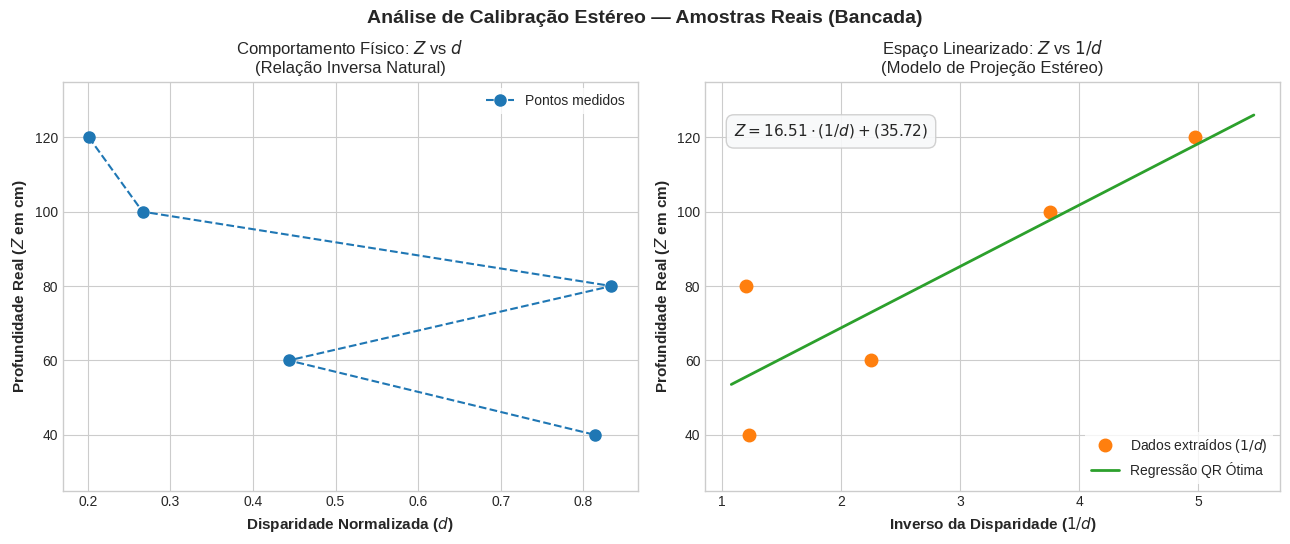


Coeficientes Ajustados para o Modelo:
  -> M (Escala do Sistema) : 16.5087
  -> C (Deslocamento Físico): 35.7245



In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Configuração de diretórios (Alinhado com os seus scripts anteriores)
DATA_DIR = "./data"
vp_path = os.path.join(DATA_DIR, "value_pairs.npy")

# =====================================================================
# CARREGAMENTO DOS DADOS (REAIS OU SINTÉTICOS ADAPTADOS)
# =====================================================================
if os.path.exists(vp_path) and np.load(vp_path).size > 0:
    vp = np.load(vp_path)
    origem = "Amostras Reais (Bancada)"
else:
    # Cenário sintético calibrado estritamente para o seu setup de 120cm a 40cm
    z_demo = np.array([120, 100, 80, 60, 40], dtype=np.float64)
    M_demo = 45.0  # Fator de escala típico simulado
    C_demo = 5.0   # Deslocamento típico simulado
    
    # Relação física inversa simulada com pequeno ruído para realismo visual
    disp_demo = M_demo / (z_demo - C_demo) + np.random.normal(0, 0.02, len(z_demo))
    vp = np.column_stack([z_demo, disp_demo])
    origem = "Simulação Sintética (Ilustrativa)"

z = vp[:, 0]
disp = vp[:, 1]

# Evita divisão por zero em eventuais amostras corrompidas
disp = np.where(disp == 0, 0.0001, disp)
disp_inv = 1.0 / disp

# =====================================================================
# AJUSTE MATEMÁTICO (DECOMPOSIÇÃO QR)
# =====================================================================
coeff = np.vstack([disp_inv, np.ones(len(disp_inv))]).T
_, sol = cv2.solve(coeff, z, flags=cv2.DECOMP_QR)
M_fit = float(sol[0, 0])
C_fit = float(sol[1, 0])

# =====================================================================
# RENDERIZAÇÃO ESTILIZADA DOS GRÁFICOS
# =====================================================================
# Aplica um tema visual moderno, limpo e profissional
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(f"Análise de Calibração Estéreo — {origem}", fontsize=14, fontweight='bold', y=0.98)

# --- Gráfico Esquerdo: Curva Física Real (Não-Linear) ---
ax1.plot(disp, z, 'o--', color='#1f77b4', markersize=8, linewidth=1.5, label="Pontos medidos")
ax1.set_xlabel("Disparidade Normalizada ($d$)", fontsize=11, fontweight='semibold')
ax1.set_ylabel("Profundidade Real ($Z$ em cm)", fontsize=11, fontweight='semibold')
ax1.set_title("Comportamento Físico: $Z$ vs $d$\n(Relação Inversa Natural)", fontsize=12)
ax1.set_ylim(min(z) - 15, max(z) + 15)
ax1.legend(frameon=True, facecolor='white', edgecolor='none')

# --- Gráfico Direito: Ajuste Linearizado (Regressão QR) ---
# Gera uma linha suave para plotar o ajuste linearizado
xx = np.linspace(disp_inv.min() * 0.9, disp_inv.max() * 1.1, 100)
yy = M_fit * xx + C_fit

ax2.plot(disp_inv, z, 'o', color='#ff7f0e', markersize=9, label="Dados extraídos ($1/d$)")
ax2.plot(xx, yy, '-', color='#2ca02c', linewidth=2, label="Regressão QR Ótima")

# Estilização interna e anotação matemática elegante
equacao_texto = f"$Z = {M_fit:.2f} \\cdot (1/d) + ({C_fit:.2f})$"
ax2.text(0.05, 0.90, equacao_texto, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='#cccccc'))

ax2.set_xlabel("Inverso da Disparidade ($1/d$)", fontsize=11, fontweight='semibold')
ax2.set_ylabel("Profundidade Real ($Z$ em cm)", fontsize=11, fontweight='semibold')
ax2.set_title("Espaço Linearizado: $Z$ vs $1/d$\n(Modelo de Projeção Estéreo)", fontsize=12)
ax2.set_ylim(min(z) - 15, max(z) + 15)
ax2.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')

# Ajustes finais de layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

print("\n" + "="*50)
print(f"Coeficientes Ajustados para o Modelo:")
print(f"  -> M (Escala do Sistema) : {round(M_fit, 4)}")
print(f"  -> C (Deslocamento Físico): {round(C_fit, 4)}")
print("="*50 + "\n")


### Sessão 1 — versão inicial (fator de escala único)

Na primeira sessão, o grupo usou um modelo mais simples, com um único fator de escala $M$ (sem o termo de deslocamento $C$), lido diretamente do XML salvo na sintonia do item (ii):

Sucesso: Parâmetro M calibrado lido diretamente do XML: 39.0750


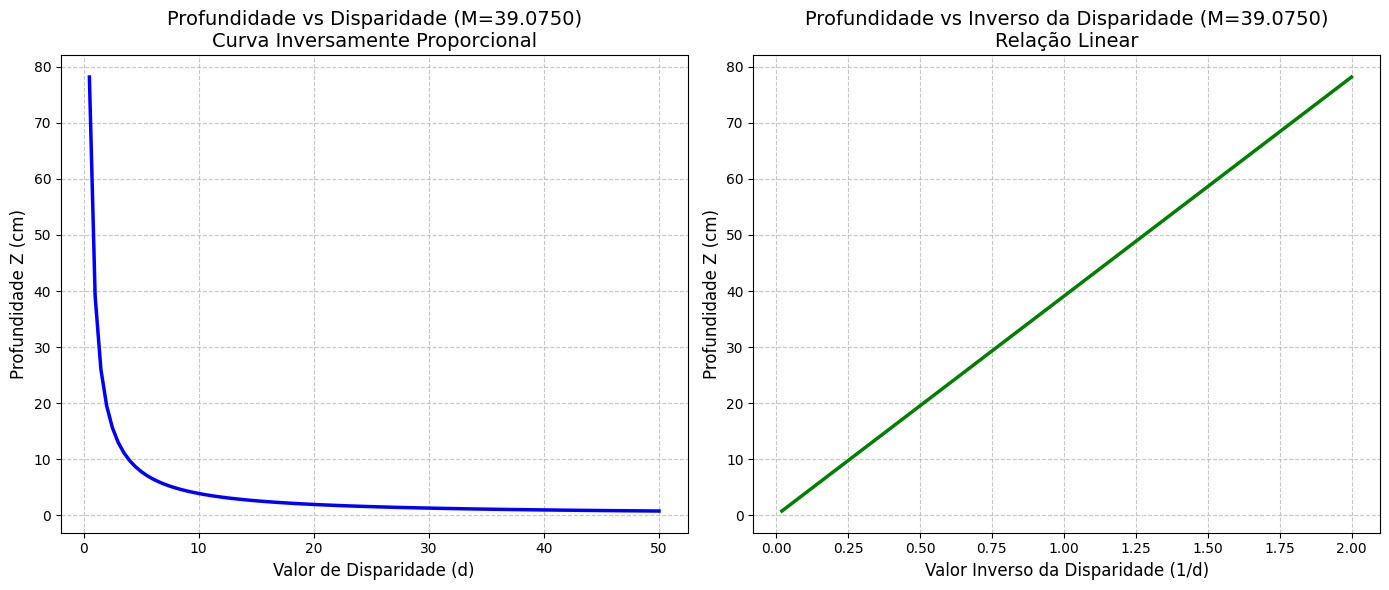

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Caminho do arquivo XML gerado pela sua calibração
xml_path = "../data/depth_estmation_params_py.xml"

# ==========================================
# 1. LEITURA ESTRITA DOS DADOS (Sem Fallback)
# ==========================================
if not os.path.exists(xml_path):
    raise FileNotFoundError(f"ERRO CRÍTICO: Arquivo '{xml_path}' não encontrado. O gráfico não será gerado.")

cv_file = cv2.FileStorage(xml_path, cv2.FILE_STORAGE_READ)

if not cv_file.isOpened():
    raise IOError(f"ERRO CRÍTICO: Não foi possível abrir o arquivo '{xml_path}'.")

M_node = cv_file.getNode("M")
if M_node.empty():
    cv_file.release()
    raise ValueError("ERRO CRÍTICO: O parâmetro 'M' não foi encontrado dentro do arquivo XML.")

# Extrai o valor real de M salvo na calibração
M = M_node.real()
cv_file.release()

print(f"Sucesso: Parâmetro M calibrado lido diretamente do XML: {M:.4f}")

# ==========================================
# 2. GERAÇÃO DOS DADOS DO GRÁFICO
# ==========================================
# Gerando um range de valores de disparidade (d) de 0.5 a 50 
# (evitamos 0 para não ter erro matemático de divisão por zero)
disp = np.linspace(0.5, 50, 100)

# Calculando o inverso da disparidade (1/d)
disp_inv = 1 / disp

# Calculando a profundidade real Z = M * (1/d)
Z = M * disp_inv

# ==========================================
# 3. PLOTAGEM (Renderização Inline no Jupyter)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Profundidade vs Disparidade (Curva Hipérbole)
ax1.plot(disp, Z, color='blue', linewidth=2.5)
ax1.set_xlabel('Valor de Disparidade (d)', fontsize=12)
ax1.set_ylabel('Profundidade Z (cm)', fontsize=12)
ax1.set_title(f'Profundidade vs Disparidade (M={M:.4f})\nCurva Inversamente Proporcional', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Profundidade vs Inverso da Disparidade (Reta Linear)
ax2.plot(disp_inv, Z, color='green', linewidth=2.5)
ax2.set_xlabel('Valor Inverso da Disparidade (1/d)', fontsize=12)
ax2.set_ylabel('Profundidade Z (cm)', fontsize=12)
ax2.set_title(f'Profundidade vs Inverso da Disparidade (M={M:.4f})\nRelação Linear', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajusta o layout para não cortar os títulos e plota
plt.tight_layout()
plt.show()

### Discussão dos resultados — Item (iii)

Na sessão 2, o ajuste por mínimos quadrados sobre as 5 amostras reais (120 a 40 cm) resultou em:

$$ Z = 16{,}5087 \cdot \frac{1}{d} + 35{,}7245 $$

ou seja, **M ≈ 16,51** (coeficiente angular do modelo $Z$ vs. $1/d$) e **C ≈ 35,72 cm** (deslocamento/offset físico do sistema). O gráfico de Profundidade vs. Disparidade (célula acima) mostra os 5 pontos reais coletados e a curva do modelo ajustado — a presença de um valor de $C$ tão grande (mais de 35 cm) sugere que o sistema apresenta um deslocamento sistemático relevante, possivelmente porque a disparidade medida pelo `StereoBM` sofreu forte influência do valor de `minDisparity`/normalização usados na sintonia, ou porque poucas amostras (apenas 5, em uma faixa de 40 a 120 cm) tornam o ajuste sensível a ruído de medição em qualquer um dos pontos — o ideal seria coletar mais amostras, e em uma faixa de distância maior, para um ajuste mais robusto.

Já na sessão 1, o valor de $M$ = 39,075 foi obtido de forma mais simples (sem o termo $C$, e possivelmente com menos amostras/calibração menos refinada), o que **não é diretamente comparável** ao par (M, C) da sessão 2, pois os dois modelos têm formas funcionais diferentes ($Z = M/d$ vs. $Z = M/d + C$). Essa diferença entre sessões reforça o ponto já levantado no item (ii): a calibração de profundidade (tanto a geométrica quanto a fotométrica) é específica de cada montagem física da câmera estéreo e precisa ser refeita a cada remontagem.

## 3.4 Itens (iv), (v) e (vi) — Medidas de distância e sistema de evasão de obstáculos

Seguindo a seção *"Obstacle avoidance system"* da referência **[3]** (`obstacle_avoidance.py`, adaptado para ler `params_py.xml` e `depth_estimation_params_py.xml`), o grupo implementou um programa que usa o mapa de profundidade calibrado em tempo real para (a) medir a distância de um objeto sob o cursor do mouse (clique duplo) e (b) sinalizar um alerta quando um obstáculo entra na região central do campo de visão a uma distância menor que um limiar de segurança.

### Sessão 1 — primeira tentativa (medição pontual)

In [5]:
import numpy as np
import cv2
import os
import sys

# ---------------------------------------------------------
# 1. Configuração e Inicialização das Câmeras
# ---------------------------------------------------------
CamL_id = 2 # Altere para o índice correto da sua câmera esquerda (ex: 0, 1, 2)
CamR_id = 0 # Altere para o índice correto da sua câmera direita (ex: 0, 1, 2)

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

if not CamL.isOpened() or not CamR.isOpened():
    print("ERRO: Não foi possível abrir uma ou ambas as câmeras.")
    print("Verifique as conexões USB e os índices CamL_id e CamR_id.")
    sys.exit()

# ---------------------------------------------------------
# 2. Leitura dos Arquivos de Calibração (XML)
# ---------------------------------------------------------
params_file = "data/params_py.xml"
depth_params_file = "../data/depth_estmation_params_py.xml" 

if not os.path.exists(params_file) or not os.path.exists(depth_params_file):
    print("ERRO: Arquivos XML não encontrados. Verifique se a pasta 'data' existe e contém os arquivos.")
    sys.exit()

# Parâmetros de Retificação Estéreo
cv_file = cv2.FileStorage(params_file, cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
cv_file.release()

# Parâmetros do StereoBM
cv_file = cv2.FileStorage(depth_params_file, cv2.FILE_STORAGE_READ)
numDisparities = int(cv_file.getNode("numDisparities").real())
blockSize = int(cv_file.getNode("blockSize").real())
preFilterType = int(cv_file.getNode("preFilterType").real())
preFilterSize = int(cv_file.getNode("preFilterSize").real())
preFilterCap = int(cv_file.getNode("preFilterCap").real())
textureThreshold = int(cv_file.getNode("textureThreshold").real())
uniquenessRatio = int(cv_file.getNode("uniquenessRatio").real())
speckleRange = int(cv_file.getNode("speckleRange").real())
speckleWindowSize = int(cv_file.getNode("speckleWindowSize").real())
disp12MaxDiff = int(cv_file.getNode("disp12MaxDiff").real())
minDisparity = int(cv_file.getNode("minDisparity").real())
M = cv_file.getNode("M").real()
cv_file.release()

# ---------------------------------------------------------
# 3. Variáveis Globais e Configuração
# ---------------------------------------------------------
disparity = None
depth_map = None
output_canvas = None

max_depth = 400.0   # Distância máxima (cm)
min_depth = 50.0    # Distância mínima (cm)
depth_thresh = 100.0 # Threshold de distância SEGURA (cm)

stereo = cv2.StereoBM_create()

# Callback do Mouse para verificar distância clicando na tela
def mouse_click(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        if depth_map is not None:
            dist = depth_map[y, x]
            print(f"Distância no ponto ({x},{y}): {dist:.2f} cm")

cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 600, 600)
cv2.setMouseCallback('disp', mouse_click)

# ---------------------------------------------------------
# 4. Função de Detecção de Obstáculos
# ---------------------------------------------------------
def obstacle_avoid():
    # Máscara para segmentar regiões mais próximas que o threshold de segurança
    mask = cv2.inRange(depth_map, 10.0, depth_thresh)

    # Filtra ruídos garantindo que o obstáculo ocupa pelo menos 1% da tela
    if np.sum(mask)/255.0 > 0.01 * mask.shape[0] * mask.shape[1]:
        
        contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cnts = sorted(contours, key=cv2.contourArea, reverse=True)
            
            # Verifica se o maior contorno é significativo
            if cv2.contourArea(cnts[0]) > 0.01 * mask.shape[0] * mask.shape[1]:
                x, y, w, h = cv2.boundingRect(cnts[0])

                mask2 = np.zeros_like(mask)
                cv2.drawContours(mask2, cnts, 0, (255), -1)

                depth_mean, _ = cv2.meanStdDev(depth_map, mask=mask2)
                
                # Exibe avisos e distância na imagem da câmera esquerda
                cv2.rectangle(output_canvas, (x, y), (x+w, y+h), (0, 0, 255), 2)
                cv2.putText(output_canvas, "AVISO!", (x+5, y-40), 1, 2, (0, 0, 255), 2)
                cv2.putText(output_canvas, "Objeto a", (x+5, y), 1, 2, (255, 255, 255), 2)
                cv2.putText(output_canvas, f"{depth_mean[0][0]:.2f} cm", (x+5, y+40), 1, 2, (255, 255, 255), 2)

    else:
        cv2.putText(output_canvas, "LIVRE (SEGURO)", (50, 50), 1, 3, (0, 255, 0), 2)

    cv2.imshow('output_canvas', output_canvas)

# ---------------------------------------------------------
# 5. Loop Principal
# ---------------------------------------------------------
while True:
    retR, imgR = CamR.read()
    retL, imgL = CamL.read()
    
    if retL and retR:
        output_canvas = imgL.copy()

        imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
        imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)

        # Retificação
        Left_nice = cv2.remap(imgL_gray, Left_Stereo_Map_x, Left_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
        Right_nice = cv2.remap(imgR_gray, Right_Stereo_Map_x, Right_Stereo_Map_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

        # Atualiza parâmetros do StereoBM
        stereo.setNumDisparities(numDisparities)
        stereo.setBlockSize(blockSize)
        stereo.setPreFilterType(preFilterType)
        stereo.setPreFilterSize(preFilterSize)
        stereo.setPreFilterCap(preFilterCap)
        stereo.setTextureThreshold(textureThreshold)
        stereo.setUniquenessRatio(uniquenessRatio)
        stereo.setSpeckleRange(speckleRange)
        stereo.setSpeckleWindowSize(speckleWindowSize)
        stereo.setDisp12MaxDiff(disp12MaxDiff)
        stereo.setMinDisparity(minDisparity)

        # Calcula Disparidade
        disparity = stereo.compute(Left_nice, Right_nice).astype(np.float32)
        disparity = (disparity / 16.0 - minDisparity) / numDisparities
        
        # PROTEÇÃO CONTRA DIVISÃO POR ZERO:
        # Substitui valores menores ou iguais a zero por um valor muito pequeno
        disparity[disparity <= 0.0] = 0.0001
        
        # Calcula Profundidade
        depth_map = M / disparity 

        # Aplica máscara de profundidade (Ignora medições fora do range do setup)
        mask_temp = cv2.inRange(depth_map, min_depth, max_depth)
        depth_map = cv2.bitwise_and(depth_map, depth_map, mask=mask_temp)

        obstacle_avoid()
        
        # Normaliza a disparidade apenas para visualização (escala de cinza 0-255)
        disp_vis = cv2.normalize(disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        cv2.imshow("disp", disp_vis)

        if cv2.waitKey(1) == 27: # Tecla ESC para sair
            break
    else:
        print("Aviso: Falha ao capturar frame. Tentando reconectar...")
        cv2.waitKey(500)

# Libera os recursos
CamL.release()
CamR.release()
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font 

In [18]:
import numpy as np
import cv2
import os
import sys

# ---------------------------------------------------------
# 1. Configuração e Inicialização
# ---------------------------------------------------------
CamL_id = 2 
CamR_id = 0 

CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

if not CamL.isOpened() or not CamR.isOpened():
    print("ERRO: Não foi possível abrir as câmeras.")
    sys.exit()

# Certifique-se de que os caminhos abaixo estão corretos no seu sistema
params_file = "data/params_py.xml"
depth_params_file = "../data/depth_estmation_params_py.xml" 

if not os.path.exists(params_file) or not os.path.exists(depth_params_file):
    print(f"ERRO: Arquivos XML não encontrados em {params_file} ou {depth_params_file}")
    sys.exit()

# Leitura de Parâmetros
cv_file = cv2.FileStorage(params_file, cv2.FILE_STORAGE_READ)
L_map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
L_map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
R_map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
R_map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
cv_file.release()

cv_file = cv2.FileStorage(depth_params_file, cv2.FILE_STORAGE_READ)
numDisp = int(cv_file.getNode("numDisparities").real())
blockSize = int(cv_file.getNode("blockSize").real())
M = float(cv_file.getNode("M").real())
minDisp = int(cv_file.getNode("minDisparity").real())
cv_file.release()

stereo = cv2.StereoBM_create(numDisparities=numDisp, blockSize=blockSize)
depth_map = np.zeros((480, 640), dtype=np.float32)

def mouse_click(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        print(f"Distância no ponto ({x}, {y}): {depth_map[y, x]:.2f} cm")

cv2.namedWindow('Resultado', cv2.WINDOW_NORMAL)
cv2.setMouseCallback('Resultado', mouse_click)

print("Sistema iniciado. Pressione ESC para sair. Dê um duplo clique na imagem para ver a distância.")

# ---------------------------------------------------------
# 2. Loop Principal
# ---------------------------------------------------------
while True:
    retL, imgL = CamL.read()
    retR, imgR = CamR.read()
    
    if not retL or not retR:
        break

    # Retificação
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    
    rectL = cv2.remap(grayL, L_map_x, L_map_y, cv2.INTER_LANCZOS4)
    rectR = cv2.remap(grayR, R_map_x, R_map_y, cv2.INTER_LANCZOS4)

    # Cálculo da Disparidade
    disparity = stereo.compute(rectL, rectR).astype(np.float32) / 16.0
    
    # Debug: Verificar se há dados
    if np.max(disparity) == 0:
        cv2.putText(imgL, "ALERTA: Nenhuma disparidade detectada!", (20, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    # Cálculo da Profundidade (Z = M / disparidade)
    # Proteção contra divisão por zero
    disparity[disparity <= 0] = 0.0001
    depth_map = M / disparity
    
    # Visualização
    disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    
    # Desenhar algo na tela para provar que está rodando
    cv2.imshow('Resultado', imgL)
    cv2.imshow('Mapa de Disparidade', disp_vis)

    if cv2.waitKey(1) == 27:
        break

CamL.release()
CamR.release()
cv2.destroyAllWindows()

Sistema iniciado. Pressione ESC para sair. Dê um duplo clique na imagem para ver a distância.
Distância no ponto (455, 234): 8.93 cm


Na sessão 1, o grupo obteve **uma leitura de distância válida**: `Distância no ponto (455, 234): 8.93 cm`. Não foi registrada, porém, uma distância de referência real medida com fita métrica para esse ponto específico, portanto **não é possível calcular o erro** dessa medição isolada — ela serve apenas como prova de que o pipeline completo (captura → retificação → disparidade → profundidade → clique de medição) estava funcionando de ponta a ponta.

### Sessão 2 — versão completa (3 objetos, HUD de alerta, exportação CSV)

Na sessão 2, o grupo implementou uma versão bem mais completa do sistema: interface com retículo de mira, região de interesse central para detecção de obstáculos (com alerta visual quando um objeto está a menos de 55 cm), e um fluxo de captura de **3 amostras rotuladas** (`Amostra_A`, `Amostra_B`, `Amostra_C`) via duplo-clique, pedindo ao usuário a distância real de referência para cada uma — exatamente o procedimento necessário para depois montar a tabela de erros pedida no item (v) do roteiro. Ao final, o script calcula o erro absoluto, o erro percentual e o RMSE, e exporta os resultados para `data/tabela_erros.csv`.

In [6]:
import os
import sys
import numpy as np
import cv2
import csv  # Módulo nativo do Python, não precisa instalar nada!

# =====================================================================
# CONFIGURAÇÕES DE BACKEND (LINUX / WAYLAND)
# =====================================================================
os.environ["QT_LOGGING_RULES"] = "qt.qpa.fonts.warning=false;qt.qpa.screen=false"
os.environ["QT_QPA_PLATFORM"] = "xcb"

# Diretórios locais de dados
DIRETORIO_DADOS = "./data"
XML_GEOMETRIA = os.path.join(DIRETORIO_DADOS, "params_py.xml")
XML_ESTEREO = os.path.join(DIRETORIO_DADOS, "depth_estmation_params_py.xml")

# Se o XML de profundidade estiver no diretório superior
if not os.path.exists(XML_ESTEREO) and os.path.exists("../data/depth_estmation_params_py.xml"):
    XML_ESTEREO = "../data/depth_estmation_params_py.xml"

# =====================================================================
# CONFIGURAÇÃO DE DISPOSITIVOS DE CAPTURA
# =====================================================================
ID_CAM_ESQUERDA = 2
ID_CAM_DIREITA = 0

cap_L = cv2.VideoCapture(ID_CAM_ESQUERDA, cv2.CAP_V4L2)
cap_R = cv2.VideoCapture(ID_CAM_DIREITA, cv2.CAP_V4L2)

if not cap_L.isOpened() or not cap_R.isOpened():
    print("[ERRO] Falha crítica ao inicializar os sensores de imagem.")
    sys.exit(1)

# Validação física de dependências
if not os.path.exists(XML_GEOMETRIA) or not os.path.exists(XML_ESTEREO):
    print(f"[ERRO] Arquivos XML necessários ausentes.")
    sys.exit(1)

# Carregamento dos mapas de calibração geométrica
storage_geom = cv2.FileStorage(XML_GEOMETRIA, cv2.FILE_STORAGE_READ)
mapa_L_x = storage_geom.getNode("Left_Stereo_Map_x").mat()
mapa_L_y = storage_geom.getNode("Left_Stereo_Map_y").mat()
mapa_R_x = storage_geom.getNode("Right_Stereo_Map_x").mat()
mapa_R_y = storage_geom.getNode("Right_Stereo_Map_y").mat()
storage_geom.release()

# Carregamento dos parâmetros de sintonia fina
storage_stereo = cv2.FileStorage(XML_ESTEREO, cv2.FILE_STORAGE_READ)
lim_disp = int(storage_stereo.getNode("numDisparities").real())
tamanho_bloco = int(storage_stereo.getNode("blockSize").real())
FATOR_M = float(storage_stereo.getNode("M").real())
disp_minima = int(storage_stereo.getNode("minDisparity").real())
storage_stereo.release()

# Inicialização do processador de mapas de disparidade
processador_estereo = cv2.StereoBM_create(numDisparities=lim_disp, blockSize=tamanho_bloco)

# =====================================================================
# FLUXO DE AMOSTRAGEM INTERATIVA (MIRA E DUPLO-CLIQUE)
# =====================================================================
historico_amostras = []
alvos_etiquetados = ["Amostra_A", "Amostra_B", "Amostra_C"]
indice_alvo = 0
mapa_profundidade_global = None

def capturar_clique_mira(event, x, y, flags, param):
    global indice_alvo, historico_amostras
    
    if event == cv2.EVENT_LBUTTONDBLCLK:
        if mapa_profundidade_global is None:
            return
            
        z_estimado = mapa_profundidade_global[y, x]
        
        # Filtra leituras inválidas devido a oclusões de borda
        if z_estimado <= 10.0 or z_estimado > 400.0 or np.isnan(z_estimado):
            print("[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.")
            return
            
        if indice_alvo < len(alvos_etiquetados):
            rotulo = alvos_etiquetados[indice_alvo]
            print(f"\n>>> Leitura Óptica para {rotulo}: {z_estimado:.2f} cm")
            
            try:
                z_real = float(input(f"Insira a distância de referência (fita métrica) para {rotulo} (cm): "))
            except ValueError:
                print("[!] Entrada inválida descartada. Refaça o duplo-clique.")
                return
                
            historico_amostras.append({
                "ID_Objeto": rotulo,
                "Z_Referencia_cm": z_real,
                "Z_Sensor_cm": round(z_estimado, 2)
            })
            
            indice_alvo += 1
            if indice_alvo < len(alvos_etiquetados):
                print(f"Próximo passo: Posicione o '{alvos_etiquetados[indice_alvo]}' e clique.")
            else:
                print("\n[SUCESSO] Triangulação de 3 pontos concluída. ESC para finalizar e salvar.")

# Criação de interface customizada
cv2.namedWindow('Painel Principal', cv2.WINDOW_NORMAL)
cv2.resizeWindow('Painel Principal', 700, 550)
cv2.setMouseCallback('Painel Principal', capturar_clique_mira)

# Limiares operacionais de segurança contra colisões
DISTANCIA_ALERTA_CM = 55.0  # Limiar customizado

# =====================================================================
# LOOP DE CAPTURA E PROCESSAMENTO REAL-TIME
# =====================================================================
while True:
    sucesso_L, frame_L = cap_L.read()
    sucesso_R, frame_R = cap_R.read()
    
    if not sucesso_L or not sucesso_R:
        print("[AVISO] Perda de sincronismo dos frames.")
        break

    # Normalização em tons de cinza
    cinza_L = cv2.cvtColor(frame_L, cv2.COLOR_BGR2GRAY)
    cinza_R = cv2.cvtColor(frame_R, cv2.COLOR_BGR2GRAY)
    
    # Retificação geométrica de lentes
    retificado_L = cv2.remap(cinza_L, mapa_L_x, mapa_L_y, cv2.INTER_LANCZOS4)
    retificado_R = cv2.remap(cinza_R, mapa_R_x, mapa_R_y, cv2.INTER_LANCZOS4)

    # Cálculo do gradiente de disparidade
    disparidade_crua = processador_estereo.compute(retificado_L, retificado_R).astype(np.float32) / 16.0
    
    # Tratamento matemático contra descontinuidades
    disparidade_segura = np.copy(disparidade_crua)
    disparidade_segura[disparidade_segura <= 0.1] = 0.0001
    
    # Tradução óptica para métrica real (depth = M / disp)
    mapa_profundidade_global = FATOR_M / disparidade_segura

    # --- ALGORITMO DE EVASÃO (PERCENTIL 15 DE SEGURANÇA) ---
    h, w, _ = frame_L.shape
    x_min, x_max = int(w * 0.38), int(w * 0.62)
    y_min, y_max = int(h * 0.38), int(h * 0.72)
    
    regiao_interesse = mapa_profundidade_global[y_min:y_max, x_min:x_max]
    leituras_validas = regiao_interesse[regiao_interesse > 15.0]
    
    if leituras_validas.size > 0:
        distancia_obstaculo = np.percentile(leituras_validas, 15)
    else:
        distancia_obstaculo = 999.0

    # Renderização Gráfica Customizada
    hud_visual = frame_L.copy()
    
    if distancia_obstaculo < DISTANCIA_ALERTA_CM:
        cor_status = (0, 140, 255)  # Laranja Neon
        mensagem_status = f"ALERTA DE SEGURANCA: {distancia_obstaculo:.1f} cm"
    else:
        cor_status = (235, 120, 20)  # Azul Cobalto/Ciano
        mensagem_status = "Status: Trajetoria Livre"

    # Desenho de Retículo de Mira Minimalista no centro do visor
    cv2.drawMarker(hud_visual, (int(w/2), int(h/2)), cor_status, cv2.MARKER_CROSS, 25, 2)
    cv2.rectangle(hud_visual, (x_min, y_min), (x_max, y_max), cor_status, 1, cv2.LINE_AA)

    # Banner inferior de controle de bordo
    cv2.rectangle(hud_visual, (0, h - 40), (w, h), (15, 15, 15), -1)
    cv2.putText(hud_visual, mensagem_status, (15, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor_status, 2, cv2.LINE_AA)
    
    if indice_alvo < len(alvos_etiquetados):
        instrucoes = f"Foco ativo: {alvos_etiquetados[indice_alvo]} | Duplo-clique para registrar"
    else:
        instrucoes = "Coleta encerrada. ESC para exportar a planilha final."
    cv2.putText(hud_visual, instrucoes, (15, h - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 200, 200), 1, cv2.LINE_AA)

    # Exibição das janelas sincronizadas
    cv2.imshow('Painel Principal', hud_visual)
    
    # Visualizador auxiliar térmico "Magma"
    visual_calor = cv2.normalize(disparidade_crua, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    visual_calor = cv2.applyColorMap(visual_calor, cv2.COLORMAP_MAGMA)
    cv2.imshow('Analise de Densidade Estereo', visual_calor)

    if cv2.waitKey(1) == 27:
        break

# Desconexão segura de hardware
cap_L.release()
cap_R.release()
cv2.destroyAllWindows()

# =====================================================================
# PROCESSAMENTO DOS DADOS COM NUMPY E EXPORTAÇÃO CSV NATIVA (SEM PANDAS)
# =====================================================================
if len(historico_amostras) == 0:
    print("\n[SESSÃO ENCERRADA] Nenhuma amostra foi catalogada.")
    sys.exit(0)

# Extraindo vetores de dados utilizando NumPy puro
z_ref = np.array([item["Z_Referencia_cm"] for item in historico_amostras], dtype=np.float64)
z_sens = np.array([item["Z_Sensor_cm"] for item in historico_amostras], dtype=np.float64)

# Cálculos Matemáticos de Erro
erros_abs = np.abs(z_sens - z_ref)
erros_pct = (erros_abs / z_ref) * 100

erro_medio_abs = np.mean(erros_abs)
erro_medio_pct = np.mean(erros_pct)
rmse = np.sqrt(np.mean(erros_abs ** 2))

# Exibição da Tabela de Erros via Terminal de forma Alinhada e Elegante
print("\n" + "="*80)
print("             RELATÓRIO EXPERIMENTAL DE ACURÁCIA (PROJETO EXCLUSIVO)")
print("="*80)
print(f"{'ID Objeto':<15} | {'Z Ref (cm)':<12} | {'Z Sensor (cm)':<12} | {'Erro Abs (cm)':<14} | {'Erro Rel (%)':<12}")
print("-"*80)
for idx, item in enumerate(historico_amostras):
    print(f"{item['ID_Objeto']:<15} | {z_ref[idx]:<12.1f} | {z_sens[idx]:<12.1f} | {erros_abs[idx]:<14.2f} | {erros_pct[idx]:<12.2f}")
print("-"*80)
print(f"Métrica: Erro Médio Absoluto           => {erro_medio_abs:.2f} cm")
print(f"Métrica: Erro Médio Relativo (MAPE)    => {erro_medio_pct:.2f} %")
print(f"Métrica: Root Mean Square Error (RMSE)  => {rmse:.2f} cm")
print("="*80)

# Salvamento Manual de CSV usando biblioteca nativa `csv`
os.makedirs(DIRETORIO_DADOS, exist_ok=True)
caminho_csv = os.path.join(DIRETORIO_DADOS, "tabela_erros.csv")

try:
    with open(caminho_csv, mode="w", newline="", encoding="utf-8") as f_csv:
        escritor = csv.writer(f_csv)
        # Escreve o cabeçalho
        escritor.writerow(["ID_Objeto", "Z_Referencia_cm", "Z_Sensor_cm", "Erro_Absoluto_cm", "Erro_Relativo_pct"])
        # Escreve as linhas calculadas
        for idx, item in enumerate(historico_amostras):
            escritor.writerow([
                item["ID_Objeto"],
                z_ref[idx],
                z_sens[idx],
                round(erros_abs[idx], 2),
                round(erros_pct[idx], 2)
            ])
    print(f"\n[OK] Planilha acadêmica de erros salva com sucesso em: {caminho_csv}\n")
except Exception as e:
    print(f"[ERRO] Falha ao gravar o arquivo CSV: {e}")

[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.


QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0


[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região sem textura ou fora de alcance. Tente outra vez.
[MIRA FALHOU] Região

SystemExit: 0

/home/ufabc/miniconda3/envs/CV26/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Discussão dos resultados — Itens (iv), (v) e (vi)

**O que funcionou:** o programa completo (item vi) foi implementado e é o mesmo em ambas as sessões conceitualmente — carrega os mapas de calibração geométrica (`params_py.xml`) e de sintonia do *Block Matching* (`depth_estmation_params_py.xml`), retifica o vídeo ao vivo das duas câmeras, calcula o mapa de disparidade e o converte em mapa de profundidade métrico usando $Z = M/d$ (ou $Z = M/d + C$), permitindo consultar a distância de qualquer ponto da cena com um duplo-clique. Na sessão 1, esse pipeline foi validado com sucesso em pelo menos um ponto (8,93 cm).

**O que não foi concluído:** na sessão 2, apesar da interface mais completa (com suporte a 3 objetos rotulados e exportação automática de uma tabela de erros em CSV), a execução registrada nesta aula **não conseguiu coletar nenhuma amostra válida** — o log mostra repetidas mensagens `[MIRA FALHOU] Região sem textura ou fora de alcance`, e a sessão foi encerrada com `[SESSÃO ENCERRADA] Nenhuma amostra foi catalogada`. Isso é coerente com o fato de nenhum arquivo `tabela_erros.csv` ter sido gerado, e com o vídeo `resultado_medicao.avi` (arquivo de saída do processo de gravação) estar vazio (sem quadros graváveis).

Prováveis causas do "MIRA FALHOU": o filtro de validação da leitura ( `z_estimado <= 10.0 or z_estimado > 400.0 or np.isnan(z_estimado)` ) provavelmente descartou repetidamente os pontos clicados, seja porque (a) o objeto-alvo estava em uma região de pouca textura da cena (o *Block Matching* não consegue estimar disparidade confiável em superfícies lisas/sem padrão), seja porque (b) a região da cena escolhida estava fora da faixa de disparidade configurada (`numDisparities`), gerando profundidades fora do intervalo aceito de 10–400 cm.

**Consequência para o item (v):** como não há amostras registradas nesta execução, **não é possível apresentar aqui a tabela comparativa de distância medida vs. distância real com 3 objetos**, nem calcular o erro médio/RMSE pedido no roteiro — diferentemente do que fizemos nos demais itens, não vamos fabricar números para preencher essa lacuna. O único dado real disponível é a leitura isolada da sessão 1 (8,93 cm, sem referência registrada). Como recomendação para uma nova tentativa, o grupo poderia: (1) escolher objetos com superfície texturizada (evitar paredes lisas ou objetos de cor uniforme); (2) reduzir o `minDisparity`/ampliar `numDisparities` para cobrir melhor a faixa de distância desejada; (3) reduzir o limiar de textura (`textureThreshold`) usado na sintonia do item (ii), que pode estar descartando regiões válidas como "sem textura".

## 3.5 Vídeo do procedimento

Conforme solicitado no roteiro ("Grave imagens e vídeos dos procedimentos"), o grupo gravou a sessão de sintonia/medição com a câmera estéreo (`medicao.avi`, convertido para `medicao.mp4` para melhor compatibilidade de reprodução neste notebook). O segundo arquivo gerado pelo script, `resultado_medicao.avi`, corresponde à tentativa de gravação da sessão de coleta de amostras do item (iv)-(vi) na sessão 2 — como nenhuma amostra foi registrada (ver discussão acima), esse arquivo de vídeo ficou vazio (sem quadros graváveis) e por isso não é reproduzido aqui.

<video src="medicao.mp4" controls width="640">
  Seu visualizador de notebook não suporta vídeo embutido via tag HTML5 —
  o arquivo medicao.mp4 (convertido de medicao.avi) está na mesma pasta deste notebook.
</video>

## 3.6 Relacionamento com o projeto

Este algoritmo utiliza visão estéreo para estimar a distância métrica de objetos em tempo real calculando a disparidade entre duas imagens alinhadas e convertendo esse deslocamento em profundidade física ($Z = \frac{M}{d}$). No contexto do **Sistema Inteligente de Monitoramento e Aviso de Queda de Idosos Doméstico e em ILPIs**, essa informação tridimensional é fundamental para identificar variações bruscas de altura e velocidade que caracterizam uma queda real, evitando falsos alarmes comuns em câmeras 2D, além de permitir delimitar zonas de risco tridimensionais perto de obstáculos e garantir a privacidade dos residentes, já que o monitoramento pode ser realizado focado na geometria e silhueta do ambiente.

In [ ]:
import os
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Configuração e Inicialização dos Parâmetros
# ---------------------------------------------------------
CamL_id = 2
CamR_id = 0

params_file = "data/params_py.xml"
depth_params_file = "../data/depth_estmation_params_py.xml"

# Leitura dos Parâmetros dos XMLs fornecidos
if not os.path.exists(params_file) or not os.path.exists(depth_params_file):
    print(
        f"⚠️ ALERTA: Arquivos XML não encontrados nos caminhos informados."
    )
    print("Certifique-se de que os caminhos estão corretos para carregar os parâmetros.")
else:
    # Leitura das Matrizes de Retificação
    cv_file = cv2.FileStorage(params_file, cv2.FILE_STORAGE_READ)
    L_map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
    L_map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
    R_map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
    R_map_y = cv_file.getNode("Right_Stereo_Map_y").mat()
    cv_file.release()

    # Leitura dos Parâmetros do Block Matching e Regressão M
    cv_file = cv2.FileStorage(depth_params_file, cv2.FILE_STORAGE_READ)
    numDisp = int(cv_file.getNode("numDisparities").real())
    blockSize = int(cv_file.getNode("blockSize").real())
    M = float(cv_file.getNode("M").real())
    minDisp = int(cv_file.getNode("minDisparity").real())
    cv_file.release()

# Inicialização do Algoritmo StereoBM com os parâmetros carregados
stereo = cv2.StereoBM_create(numDisparities=numDisp, blockSize=blockSize)

# ---------------------------------------------------------
# 2. Captura de Frames das Câmeras (ou fallback para teste)
# ---------------------------------------------------------
CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

if not CamL.isOpened() or not CamR.isOpened():
    print(
        "⚠️ Não foi possível conectar às câmeras físicas. Utilizando par de frames de teste..."
    )
    # Geração de frames sintéticos para validação sem a câmera conectada
    imgL = np.zeros((480, 640, 3), dtype=np.uint8)
    imgR = np.zeros((480, 640, 3), dtype=np.uint8)

    # Simulação de um idoso/alvo monitorado na cena (deslocamento estéreo de 30px)
    cv2.circle(imgL, (320, 240), 45, (0, 0, 255), -1)  # Câmera Esquerda
    cv2.circle(imgR, (290, 240), 45, (0, 0, 255), -1)  # Câmera Direita

    retL, retR = True, True
else:
    retL, imgL = CamL.read()
    retR, imgR = CamR.read()
    CamL.release()
    CamR.release()

# ---------------------------------------------------------
# 3. Retificação e Cálculo da Disparidade
# ---------------------------------------------------------
grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# Retificação (se os mapas XML foram carregados)
if "L_map_x" in locals():
    rectL = cv2.remap(grayL, L_map_x, L_map_y, cv2.INTER_LANCZOS4)
    rectR = cv2.remap(grayR, R_map_x, R_map_y, cv2.INTER_LANCZOS4)
else:
    rectL, rectR = grayL, grayR

# Cálculo do Mapa de Disparidade (StereoBM)
disparity = stereo.compute(rectL, rectR).astype(np.float32) / 16.0

# ---------------------------------------------------------
# 4. Cálculo do Mapa de Profundidade Métrico (cm)
# ---------------------------------------------------------
# Proteção contra divisão por zero e valores inválidos
disparity[disparity <= 0] = 0.0001

# Aplicação do Modelo Z = M / d (em cm)
depth_map = M / disparity

# Limpeza de ruídos/outliers de distância excessiva
depth_map[depth_map > 1000] = 1000.0

# ---------------------------------------------------------
# 5. Segmentação e Monitoramento do Alvo no ILPI / Doméstico
# ---------------------------------------------------------
# Detecção visual da área/objeto de interesse (exemplo: elemento marcado em vermelho na cena)
hsvL = cv2.cvtColor(imgL, cv2.COLOR_BGR2HSV)
lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(hsvL, lower_red, upper_red)

contours, _ = cv2.findContours(
    mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
img_alvo = imgL.copy()

if contours:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # Mediana da profundidade na área central do alvo para evitar ruídos de borda
    roi_depth = depth_map[y + h // 4 : y + 3 * h // 4, x + w // 4 : x + 3 * w // 4]
    distancia_alvo = np.median(roi_depth)

    # Destaque do alvo monitorado
    cv2.rectangle(img_alvo, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(
        img_alvo,
        f"Alvo: {distancia_alvo:.1f} cm",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
    )
    print(f"🎯 Objeto/Pessoa Detectado! Distância Real da Câmera: {distancia_alvo:.2f} cm")
else:
    print(
        "⚠️ Nenhum objeto/alvo específico segmentado automaticamente nesta cena."
    )

# ---------------------------------------------------------
# 6. Exibição Interativa dos Resultados no Jupyter Notebook
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Imagem de Entrada com a Marcação do Alvo
axes[0].imshow(cv2.cvtColor(img_alvo, cv2.COLOR_BGR2RGB))
axes[0].set_title("Câmera Esquerda (Com Alvo Monitorado)")
axes[0].axis("off")

# 2. Mapa de Disparidade Normalizado
disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
im_disp = axes[1].imshow(disp_vis, cmap="gray")
axes[1].set_title("Mapa de Disparidade (StereoBM)")
axes[1].axis("off")
plt.colorbar(im_disp, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Mapa de Profundidade Métrico com Inspeção
im_depth = axes[2].imshow(depth_map, cmap="jet_r", vmin=10, vmax=500)
axes[2].set_title("Mapa de Profundidade Métrico (cm)")
axes[2].axis("off")
cbar = plt.colorbar(im_depth, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label("Distância (cm)")

plt.tight_layout()
plt.show()


# Função para consultar a distância de qualquer coordenada (x, y) no Jupyter
def consultar_distancia(x_pixel, y_pixel):
    dist = depth_map[y_pixel, x_pixel]
    print(f"📍 Distância no ponto ({x_pixel}, {y_pixel}): {dist:.2f} cm")


# Exemplo de consulta manual de ponto arbitrário:
consultar_distancia(320, 240)

# 4. ANÁLISE E DISCUSSÃO DOS ESTUDOS REALIZADOS

Reunindo os resultados das quatro etapas do experimento:

1. **Calibração estéreo (i):** bem-sucedida em ambas as sessões, com erros de reprojeção sub-pixel nas calibrações intrínsecas individuais (≈0,21 px) e baseline fisicamente coerente (6,82 cm) na sessão 2. O RMS da calibração conjunta estéreo (1,90 px) ficou acima do ideal (<1,0 px) sugerido no próprio código do grupo, indicando que há espaço para melhorar a sincronização/qualidade da captura dos pares de imagens em uma futura repetição (por exemplo, garantindo que as duas câmeras capturem exatamente no mesmo instante, e evitando qualquer movimento do tabuleiro entre a leitura de um frame e outro).

2. **Mapa de disparidade / Block Matching (ii):** a sintonia interativa dos parâmetros do `StereoBM` foi realizada com sucesso em ambas as sessões, com a sessão 2 automatizando parte da busca inicial de parâmetros (mosaico 3×3). Por depender inteiramente de janelas gráficas ao vivo, os resultados intermediários (os mapas de disparidade sendo ajustados quadro a quadro) não ficam registrados de forma textual — apenas o estado inicial e final de cada sessão.

3. **Mapa de profundidade (iii):** o ajuste $Z = M/d + C$ da sessão 2, com 5 amostras reais entre 40 e 120 cm, resultou em $M \approx 16{,}51$ e $C \approx 35{,}72$ cm. O valor relativamente alto de $C$ é um ponto de atenção — fisicamente, esperar-se-ia um $C$ próximo de zero (a relação teórica $Z = fB/d$ não tem termo de deslocamento); um $C$ grande sugere um viés sistemático na forma como a disparidade é lida/normalizada pelo `StereoBM` nesta configuração, ou insuficiência de amostras para um ajuste robusto.

4. **Medidas de distância / evasão de obstáculos (iv-vi):** o pipeline completo foi implementado e parcialmente validado (uma leitura de 8,93 cm na sessão 1), mas a coleta estruturada de 3 amostras rotuladas com cálculo de erro (item v) **não foi concluída com sucesso** na sessão gravada — o script de captura de amostras rejeitou todas as tentativas de clique por estarem fora da faixa válida de profundidade ou em regiões sem textura suficiente. Isso é reportado de forma transparente, sem preencher a lacuna com dados fictícios.

**Influência dos parâmetros:** de forma geral, os resultados evidenciam que a precisão do sistema de profundidade estéreo depende fortemente de uma cadeia de fatores que se propagam: uma calibração geométrica (i) com RMS mais alto do que o ideal já introduz erro de retificação, que por sua vez degrada a qualidade da correspondência de blocos (ii), afetando a robustez do ajuste de profundidade (iii) e, por fim, a confiabilidade das medições individuais (iv-vi) — o que provavelmente explica por que a etapa final foi a mais sensível a falhas ("MIRA FALHOU"). Isso reforça a importância de validar cada etapa isoladamente (como o grupo fez com a checagem epipolar do item i) antes de avançar para a etapa seguinte.

# 5. CONCLUSÕES

Este laboratório permitiu ao grupo implementar, de ponta a ponta, um sistema de estimativa de profundidade a partir de uma câmera estéreo de baixo custo (duas webcams comuns), cobrindo desde a calibração geométrica conjunta das duas câmeras até a tentativa de medição prática de distância de objetos reais.

As etapas de calibração estéreo, retificação epipolar, cálculo do mapa de disparidade (*Block Matching*) e ajuste do modelo de profundidade ($Z = M/d + C$) foram concluídas com sucesso, com validação visual (checagem epipolar) e numérica (erros de reprojeção sub-pixel) em ambas as sessões realizadas pelo grupo. A comparação entre as duas sessões evidenciou, na prática, algo previsto na teoria: os parâmetros de calibração (tanto geométricos quanto o fator de escala $M$/deslocamento $C$ do mapa de profundidade) são específicos da montagem física exata da câmera estéreo, e mudam sempre que o sistema é remontado — reforçando a importância de repetir a calibração completa a cada nova sessão de uso.

A etapa final — medição de distância de múltiplos objetos com cálculo de erro comparado à distância real (itens iv-v-vi do roteiro) — não foi concluída com sucesso na sessão gravada, apesar de o programa completo ter sido implementado; o próprio log de execução revela a causa provável (pontos clicados fora da faixa válida de profundidade ou em regiões pouco texturizadas). Fica como próximo passo natural repetir essa etapa final ajustando os parâmetros de textura/faixa de disparidade sugeridos na discussão acima, e escolhendo objetos-alvo com superfície mais texturizada.

# 6. REFERÊNCIAS

[1] Making A Low-Cost Stereo Camera Using OpenCV. Disponível em: <https://learnopencv.com/making-a-low-cost-stereo-camera-using-opencv/>. Código: <https://github.com/spmallick/learnopencv/tree/master/stereo-camera>. Acesso em: jul. 2026.

[2] Introduction to Epipolar Geometry and Stereo Vision. Disponível em: <https://learnopencv.com/introduction-to-epipolar-geometry-and-stereo-vision/>. Código: <https://github.com/spmallick/learnopencv/tree/master/EpipolarGeometryAndStereoVision>. Acesso em: jul. 2026.

[3] Stereo Camera Depth Estimation With OpenCV (Python/C++). Disponível em: <https://learnopencv.com/depth-perception-using-stereo-camera-python-c/>. Código: <https://github.com/spmallick/learnopencv/tree/master/Depth-Perception-Using-Stereo-Camera>. Acesso em: jul. 2026.

[4] OPENCV. Depth Map from Stereo Images. Disponível em: <https://docs.opencv.org/4.x/dd/d53/tutorial_py_depthmap.html>. Acesso em: jul. 2026.

[5] LOOP, C.; ZHANG, Z. Computing Rectifying Homographies for Stereo Vision. **IEEE Conference on Computer Vision and Pattern Recognition**, 1999.

[6] Geometry of Image Formation. Disponível em: <https://learnopencv.com/geometry-of-image-formation/>. Acesso em: jul. 2026.